# Flexynesis 모델 비교 워크샵

**데이터**: BRCA METABRIC (gex + cna + mut)

| 섹션 | 모델 | 태스크 |
|------|------|--------|
| 0 | — | 데이터 로드 + 미니 서브셋 생성 |
| 1 | DirectPred | 분류 (CLAUDIN_SUBTYPE) |
| 2 | DirectPred | 생존분석 (OS_STATUS + OS_MONTHS) |
| 3 | supervised_vae | 분류 (CLAUDIN_SUBTYPE) |
| 4 | supervised_vae | 비지도 (target 없음) |
| 5 | MultiTripletNetwork | metric learning |
| 6 | GNN | 분류 (STRING DB 활용) |
| 7 | — | 모델 성능 비교 |

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import flexynesis
import torch
import numpy as np
import pandas as pd
from collections import Counter
torch.set_num_threads(4)

import time

print("flexynesis:", flexynesis.__version__)
print("CUDA available:", torch.cuda.is_available())

flexynesis: 1.1.7
CUDA available: True


---
## Section 0. 데이터 로드 + 미니 서브셋 생성

- 풀 데이터: gex.csv (~20k genes, 1300 samples)
- **미니 데이터**: 샘플 200개 랜덤 샘플링 → 빠른 테스트용
- `USE_MINI = True`로 설정하면 미니 데이터 사용

In [2]:
USE_MINI = True   # 빠른 테스트: True / 실제 분석: False
HPO_ITER = 3      # HPO 반복 횟수 (실제: 50+)

# 랩 공유 스토리지 경로 (다운로드 불필요)
DATA_DIR = "/data01/storage/flexynesis_workshop/brca_metabric_processed"
MINI_DIR  = "/data01/storage/flexynesis_workshop/brca_mini"


In [3]:
import shutil

def make_mini_dataset(src_dir, dst_dir, n_train=200, n_test=80, seed=42,
                       stratify_col='CLAUDIN_SUBTYPE', min_per_class=2):
    """풀 데이터에서 stratified 서브셋 생성 (클래스별 최소 min_per_class 보장)"""
    if os.path.exists(dst_dir):
        print(f"미니 데이터 이미 존재: {dst_dir}")
        return

    np.random.seed(seed)

    for split, n in [('train', n_train), ('test', n_test)]:
        src = os.path.join(src_dir, split)
        dst = os.path.join(dst_dir, split)
        os.makedirs(dst, exist_ok=True)

        clin = pd.read_csv(os.path.join(src, 'clin.csv'), index_col=0)

        # Stratified sampling: 각 클래스에서 비율대로 뽑되 min_per_class 보장
        if stratify_col and stratify_col in clin.columns:
            groups = clin.groupby(stratify_col)
            chosen_list = []
            # 1단계: 각 클래스에서 최소 min_per_class 확보
            for cls, grp in groups:
                take = max(min_per_class, int(round(len(grp) / len(clin) * n)))
                take = min(take, len(grp))
                chosen_list.append(grp.sample(take, random_state=seed))
            chosen_df = pd.concat(chosen_list)
            # 2단계: n보다 많으면 랜덤으로 줄임
            if len(chosen_df) > n:
                chosen_df = chosen_df.sample(n, random_state=seed)
            chosen = chosen_df.index
            print(f"[{split}] stratified {len(chosen)} samples")
            print('  클래스별:', chosen_df[stratify_col].value_counts().to_dict())
        else:
            chosen = clin.sample(min(n, len(clin)), random_state=seed).index

        clin.loc[chosen].to_csv(os.path.join(dst, 'clin.csv'))

        for fname in os.listdir(src):
            if fname == 'clin.csv':
                continue
            fpath = os.path.join(src, fname)
            df = pd.read_csv(fpath, index_col=0)
            valid = [s for s in chosen if s in df.columns]
            df[valid].to_csv(os.path.join(dst, fname))
            print(f"  {split}/{fname}: {df.shape[0]} features × {len(valid)} samples")

    # STRING DB 파일 복사 (GNN용)
    for f in os.listdir(src_dir):
        if f.endswith('.gz'):
            shutil.copy(os.path.join(src_dir, f), dst_dir)

    print(f"\n미니 데이터 생성 완료: {dst_dir}")

make_mini_dataset(DATA_DIR, MINI_DIR)


미니 데이터 이미 존재: ./brca_mini


### DataImporter 파라미터 레퍼런스

> **필수 입력**: `path`, `data_types` — 나머지는 모두 default 값이 있어 생략 가능

| 파라미터 | 기본값 | 필수 | 설명 |
|----------|--------|:----:|------|
| `path` | — | ✅ | train/test 폴더가 있는 상위 디렉토리 경로 |
| `data_types` | — | ✅ | 사용할 omics 레이어 리스트 (폴더 내 파일명 기준, 예: `['gex', 'cna']`) |
| `concatenate` | `False` | | `False`=intermediate fusion (레이어별 개별 encoder) / `True`=early fusion (concat 후 single encoder) |
| **Feature selection** | | | |
| `top_percentile` | `20` | | Laplacian score 상위 N% feature만 유지 |
| `min_features` | `None` | | percentile 적용 후 최소 보장 feature 수 (부족하면 하위 feature로 보충) |
| `correlation_threshold` | `0.9` | | 이 이상 상관된 feature 쌍에서 하나 제거 (낮출수록 더 공격적으로 제거) |
| `variance_threshold` | `0.01` | | 분산 하위 N% feature 제거 (높일수록 더 많이 제거, 0~1 사이) |
| **Missing value** | | | |
| `na_threshold` | `0.1` | | feature의 NA 비율이 이 이상이면 해당 feature 제거 |
| **Transform** | | | |
| `log_transform` | `False` | | `True`면 전처리 후 log1p 변환 (raw count 데이터에 유용) |
| **기타** | | | |
| `covariates` | `None` | | batch correction용 공변량 변수명 리스트 (예: `['COHORT']`, clin.csv 컬럼 기준) |
| `downsample` | `0` | | `0`=전체 샘플 / N>0이면 N개로 랜덤 다운샘플 |
| `restrict_to_features` | `None` | | 특정 feature만 사용 — **텍스트 파일 경로**를 지정 (유전자명 한 줄에 하나씩) |

> **`restrict_to_features` 파일 형식** (`.txt`): feature selection보다 먼저 적용됨 → 이 리스트 안에서만 Laplacian score 계산
> ```
> BRCA1
> BRCA2
> TP53
> ```


In [4]:
# 실제 사용할 경로 결정
PATH = MINI_DIR if USE_MINI else DATA_DIR
print(f"사용 데이터: {PATH} ({'미니' if USE_MINI else '풀'})")

# DataImporter 공통 설정
data_importer = flexynesis.data.DataImporter(
    path=PATH,
    data_types=['gex', 'cna'],        # 사용할 omics 레이어 (폴더 내 파일명 기준)
    concatenate=False,                 # False=intermediate fusion / True=early fusion (모든 레이어 concat 후 single encoder)

    # --- Feature selection ---
    top_percentile=10,                 # Laplacian score 상위 N% feature만 유지 (default: 20)
    min_features=50,                   # percentile 적용 후 최소 보장 feature 수 (너무 적어지면 이 값까지 보충)
    correlation_threshold=0.9,         # 이 이상 상관된 feature 쌍에서 하나 제거 (default: 0.9, 낮출수록 더 공격적 제거)
    variance_threshold=0.8,            # 분산 하위 N% feature 제거 (default: 0.01, 높일수록 더 많이 제거)

    # --- Missing value ---
    na_threshold=0.1,                  # feature의 NA 비율이 이 이상이면 feature 제거 (default: 0.1)

    # --- Normalization / Transform ---
    log_transform=False,               # True면 전처리 후 log1p 변환 (count 데이터에 유용)

    # --- 기타 ---
    covariates=None,                   # batch correction용 공변량 변수명 리스트 (예: ['COHORT']) clin.csv 컬럼 기준
    downsample=0,                      # 0=전체 샘플 사용 / N>0이면 N개로 랜덤 다운샘플 (USE_MINI 대신 써도 됨)
    restrict_to_features=None,         # 특정 feature 리스트만 사용 (예: 알려진 유전자 패널로 제한할 때)
)
train_dataset, test_dataset = data_importer.import_data()

사용 데이터: ./brca_mini (미니)

[INFO] ================= Importing Data =================
[INFO] Validating data folders...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing ./brca_mini/train/clin.csv...
[INFO] Importing ./brca_mini/train/cna.csv...
[INFO] Importing ./brca_mini/train/gex.csv...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing ./brca_mini/test/clin.csv...
[INFO] Importing ./brca_mini/test/cna.csv...
[INFO] Importing ./brca_mini/test/gex.csv...

[INFO] ----------------- Checking for problems with the input data ----------------- 
[INFO] Data structure is valid with no errors or warnings.

[INFO] ----------------- Processing Data (train) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Imputing NA values to median of features, affected # of cells in the matrix 2  # of rows: 2
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.

[INFO

Filtering redundant features: 100%|██████████| 412/412 [00:00<00:00, 9709.47it/s]


[INFO] Implementing feature selection using laplacian score for layer: cna with  4510 features  and  199  samples 


Filtering redundant features: 100%|██████████| 451/451 [00:00<00:00, 507547.92it/s]



[INFO] ----------------- Processing Data (test) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.

[INFO] working on layer:  cna
[INFO] Number of NA values:  0
[INFO] DataFrame cna - Removed 18033 features.
[INFO] DataFrame gex - Removed 0 samples (0.00%).
[INFO] DataFrame cna - Removed 0 samples (0.00%).

[INFO] ----------------- Harmonizing Data Sets ----------------- 

[INFO] ----------------- Finished Harmonizing ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 
[INFO] Training Data Stats:  {'feature_count in: gex': 371, 'feature_count in: cna': 451, 'sample_count': 199}
[INFO] Test Data Stats:  {'feature_count in: gex': 371, 'feature_count in: cna': 451, 'sample_count': 80}
[INFO] Merging Feature Logs...
[INFO] Data import successful.


In [5]:
print("Train:", len(train_dataset.samples), "samples")
print("Test: ", len(test_dataset.samples), "samples")
print("Features:", {k: v.shape[1] for k, v in train_dataset.dat.items()})

# CLAUDIN_SUBTYPE 분포
f = 'CLAUDIN_SUBTYPE'
lmap = train_dataset.label_mappings[f]
counts = Counter(train_dataset.ann[f].numpy())
print(f"\n{f}:")
for k, v in sorted(counts.items()):
    print(f"  {lmap[k]:15s}: {v}")

Train: 199 samples
Test:  80 samples
Features: {'gex': 371, 'cna': 451}

CLAUDIN_SUBTYPE:
  Basal          : 22
  Her2           : 23
  LumA           : 71
  LumB           : 50
  NC             : 2
  Normal         : 14
  claudin-low    : 17


In [6]:
# 결과 수집용
all_metrics = []
training_log = []

---
## Section 1. DirectPred — 분류

**구조**: per-modality MLP encoder → concat → fusion linear → supervisor MLP head  
**Loss**: Cross-entropy (categorical)

Seed set to 42
Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32}


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  109 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 22.2 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.5 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 134 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 134 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 7. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

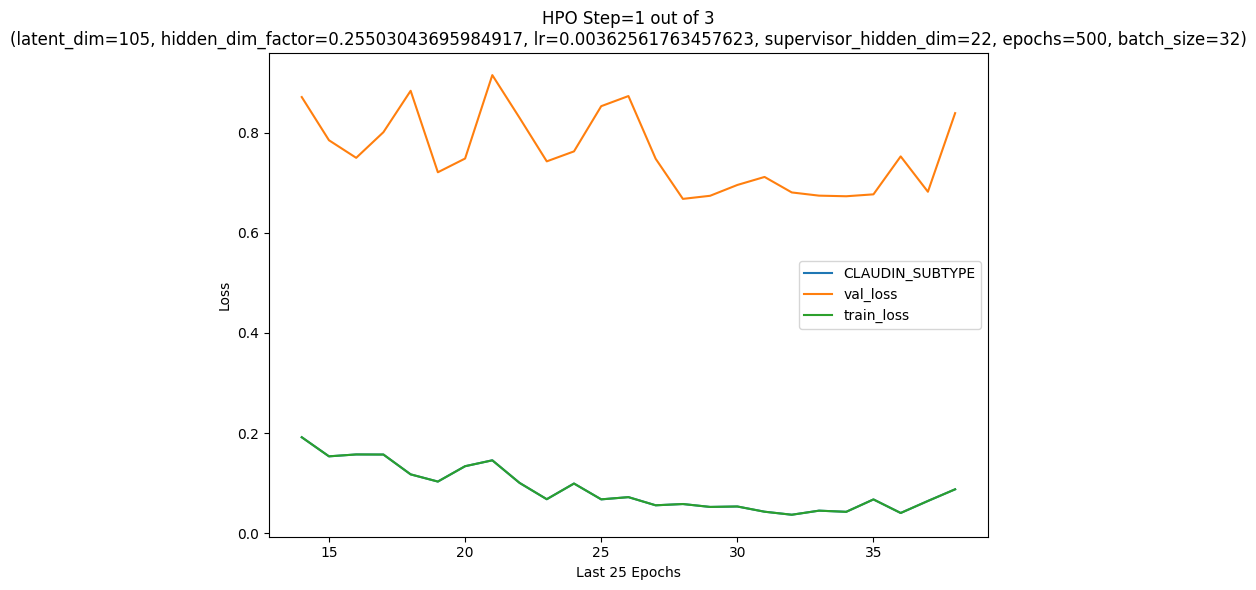

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8388789296150208     │
│         val_loss          │    0.8388789296150208     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:18<00:37, 18.64s/it, Iteration=1, Best Loss=0.839]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.8388789296150208; best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 67, 'hidden_dim_factor': 0.3001125833417066, 'lr': 0.0001930783753654713, 'supervisor_hidden_dim': 24, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  119 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │  9.0 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  1.9 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 130 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 130 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 39. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 128. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

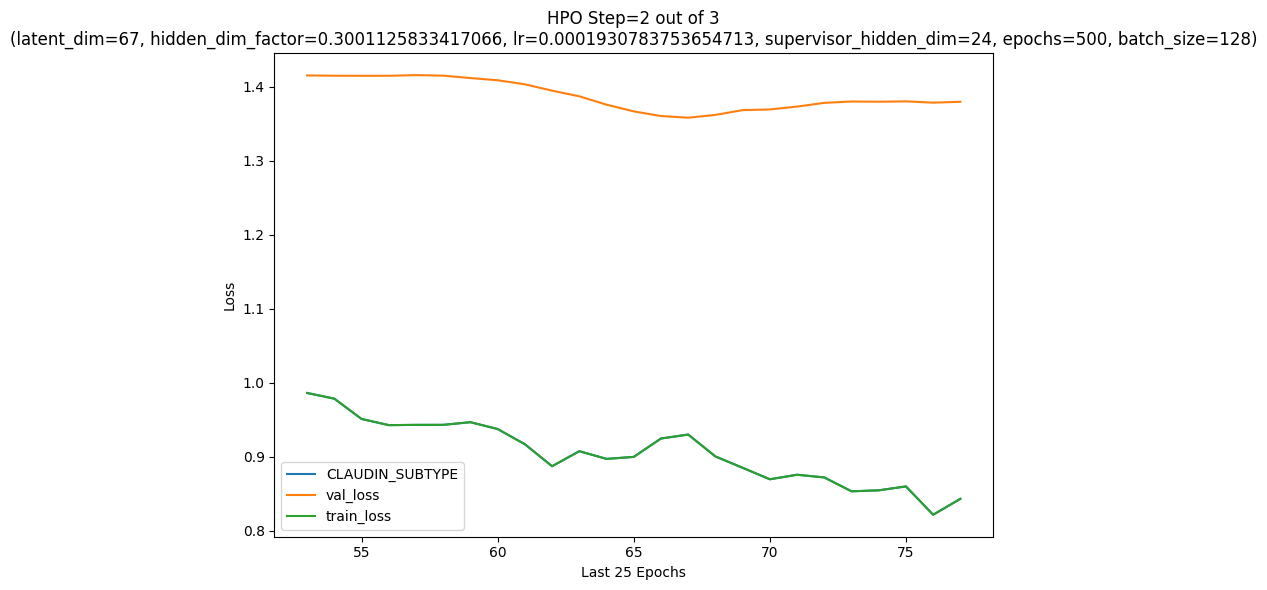

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.3795346021652222     │
│         val_loss          │    1.3795346021652222     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:43<00:22, 22.34s/it, Iteration=2, Best Loss=0.839]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.8388789296150208; best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 121, 'hidden_dim_factor': 0.2002336297523043, 'lr': 0.009647685075720105, 'supervisor_hidden_dim': 23, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 88.6 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 29.4 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  3.0 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 121 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 121 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

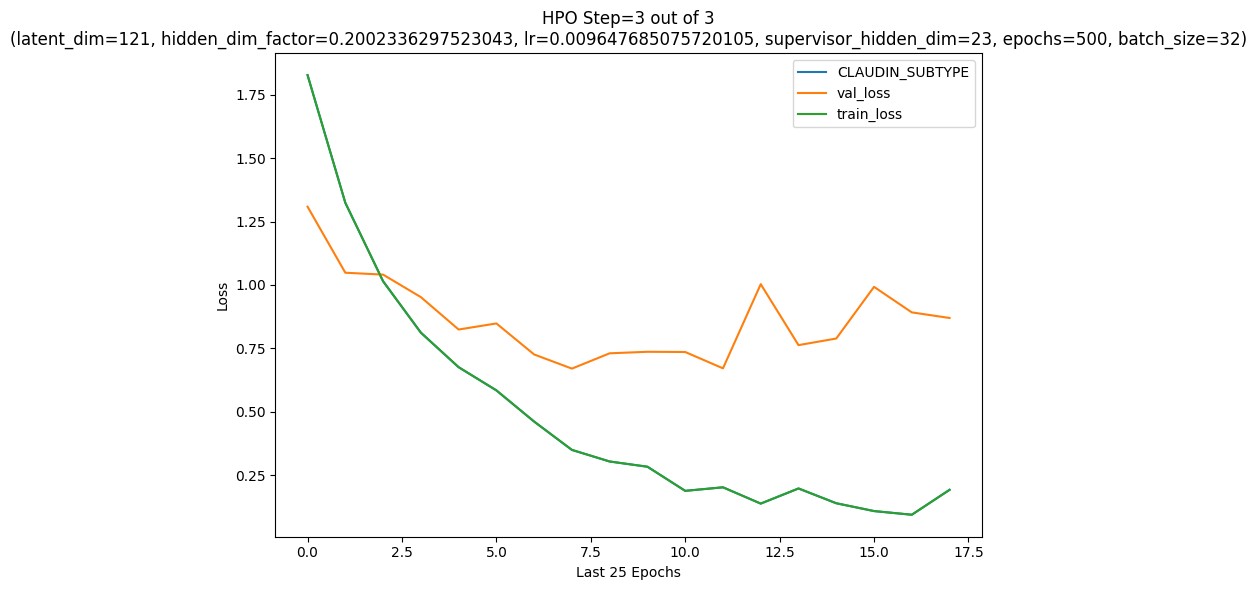

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8699294924736023     │
│         val_loss          │    0.8699294924736023     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:51<00:00, 17.27s/it, Iteration=3, Best Loss=0.839]

[INFO] current best val loss: 0.8388789296150208; best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 2 hpo iterations
Best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 38, 'batch_size': 32}
소요 시간: 0.9분 (52초)
저장 완료: ./models/DirectPred_clf.pth


In [7]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.DirectPred,  # DirectPred / supervised_vae / MultiTripletNetwork / GNN / CrossModalPred
    target_variables=['CLAUDIN_SUBTYPE'],       # 예측할 변수 리스트 (clin.csv 컬럼명)
    config_name='DirectPred',                  # HPO search space 설정 이름 (config.py 기준)

    # --- HPO 설정 ---
    n_iter=HPO_ITER,                           # Bayesian HPO 반복 횟수 (default: 10, 실제: 50+)
    config_path=None,                          # 커스텀 YAML HPO 설정 파일 경로 (None=내장 config 사용)
    val_size=0.2,                              # validation 비율 (default: 0.2)
    use_cv=False,                              # True=K-fold CV로 HPO / False=단일 train-val split (default: False)
    cv_splits=5,                               # use_cv=True일 때 fold 수 (default: 5)

    # --- 학습 설정 ---
    use_loss_weighting=True,                   # True=Kendall uncertainty weighting으로 멀티태스크 loss 자동 조정 (default: True)
    early_stop_patience=10,                    # validation loss 개선 없으면 N epoch 후 조기 종료 (-1=비활성화)
    plot_losses=True,                          # 학습 중 loss 실시간 시각화 (default: False)

    # --- 생존분석 (선택) ---
    surv_event_var=None,                       # Cox loss용 사건 변수 (0/1)
    surv_time_var=None,                        # Cox loss용 시간 변수

    # --- Batch correction (선택) ---
    batch_variables=None,                      # batch effect 보정용 변수 리스트 (예: ['COHORT'])

    # --- 디바이스 ---
    device_type=None,                          # None=자동감지 / 'gpu' / 'cpu'

    # --- GNN 전용 (선택) ---
    gnn_conv_type='GC',                        # GNN conv 타입: 'GCN', 'SAGE', 'GAT' (None=config 따름)
)
_t0 = time.time()
model_dp, params_dp = tuner.perform_tuning()
print("Best params:", params_dp)
_elapsed = time.time() - _t0
training_log.append({'model': 'DirectPred (분류)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_dp, f'./models/DirectPred_clf.pth')
print(f'저장 완료: ./models/DirectPred_clf.pth')

In [8]:
metrics_dp = flexynesis.utils.evaluate_wrapper(
    method='DirectPred',         # 결과 테이블에 표시될 모델 이름 (자유롭게 지정)
    y_pred_dict=model_dp.predict(test_dataset),  # model.predict()의 반환값
    dataset=test_dataset,        # 평가할 dataset (test)
    surv_event_var=None,         # 생존분석일 때만 지정 (예: 'OS_STATUS')
    surv_time_var=None,          # 생존분석일 때만 지정 (예: 'OS_MONTHS')
    # 반환 메트릭:
    # - categorical: balanced_acc, f1_score, kappa, average_auroc, average_aupr
    # - numerical:   mse, r2, pearson_corr
    # - survival:    cindex
)
all_metrics.append(metrics_dp)
metrics_dp

,method,var,variable_type,metric,value
0,DirectPred,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.578612
1,DirectPred,CLAUDIN_SUBTYPE,categorical,f1_score,0.717311
2,DirectPred,CLAUDIN_SUBTYPE,categorical,kappa,0.648913
3,DirectPred,CLAUDIN_SUBTYPE,categorical,average_auroc,0.914193
4,DirectPred,CLAUDIN_SUBTYPE,categorical,average_aupr,0.769647


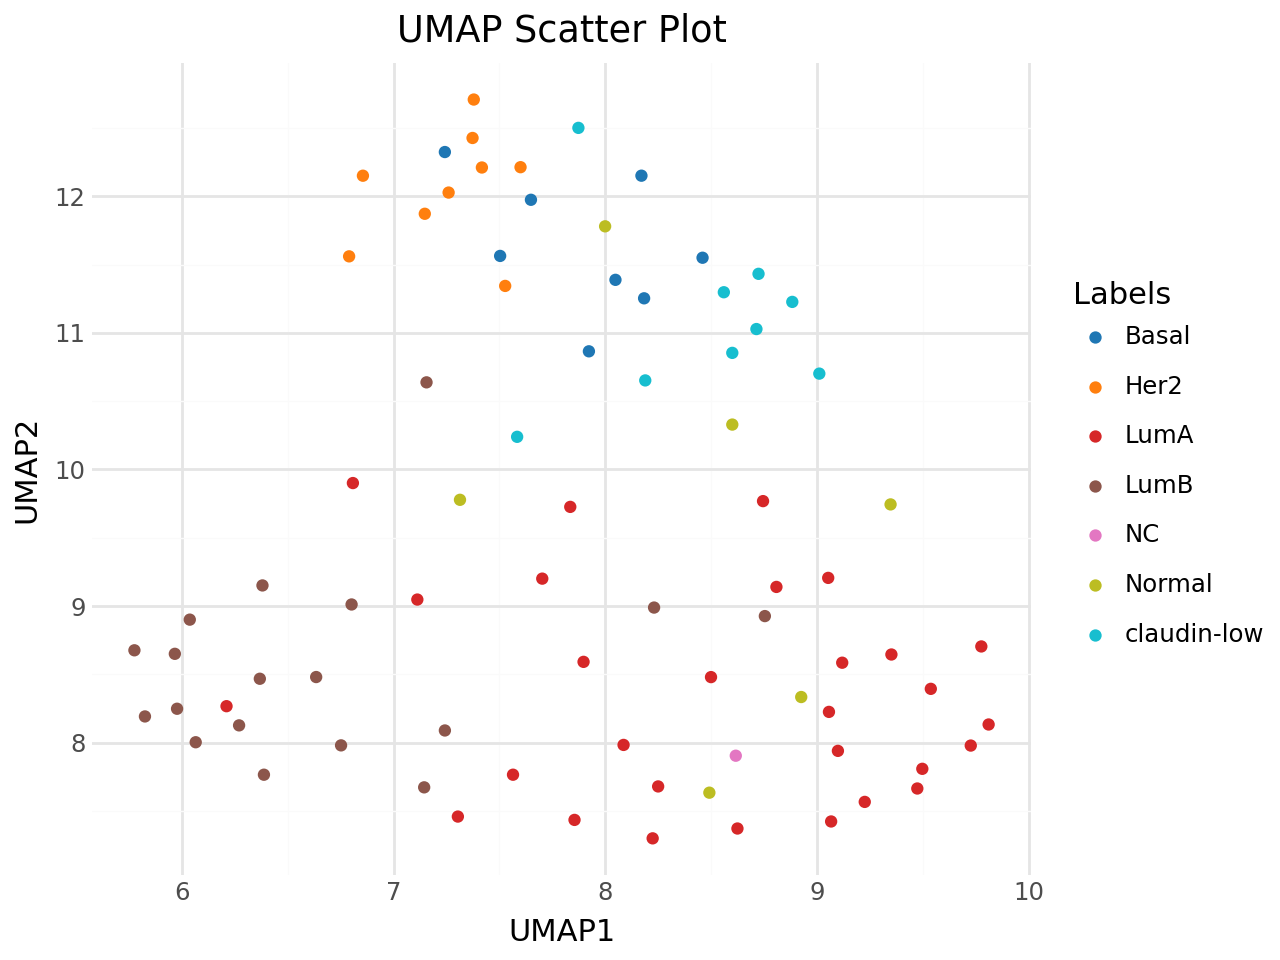

In [9]:
# model.transform(): latent embedding 추출 (samples × latent_dim DataFrame)
E_dp = model_dp.transform(test_dataset)

labels = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x] for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]

flexynesis.utils.plot_dim_reduced(
    E_dp,                        # embedding DataFrame (samples × dims)
    labels,                      # 색칠할 레이블 리스트
    method='umap',               # 차원축소 방법: 'pca' or 'umap'
    color_type='categorical',    # 'categorical'=이산형 / 'numerical'=연속형 (gradient)
    title=None,                  # 플롯 제목 (None=자동)
)

---
## Section 2. DirectPred — 생존분석

**Loss**: Cox Proportional Hazards  
**평가**: C-index (0.5=랜덤, 1.0=완벽)  
BRCA clin.csv에 `OS_STATUS` (0/1), `OS_MONTHS` 있음

Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 100, 'hidden_dim_factor': 0.31789683469365776, 'lr': 0.0045533228152233925, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  134 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 20.1 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 157 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 157 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

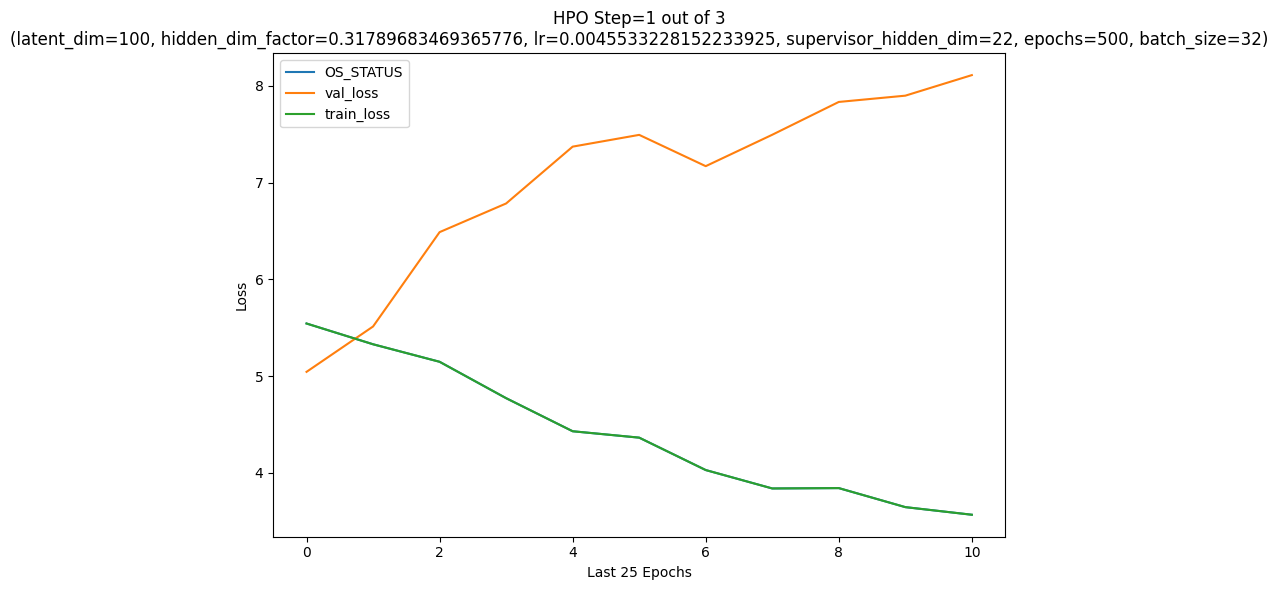

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     8.112386703491211     │
│         val_loss          │     8.112386703491211     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:06<00:12,  6.32s/it, Iteration=1, Best Loss=8.11]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 8.112386703491211; best params: {'latent_dim': 100, 'hidden_dim_factor': 0.31789683469365776, 'lr': 0.0045533228152233925, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 18, 'hidden_dim_factor': 0.2226077181057387, 'lr': 0.002417846882276413, 'supervisor_hidden_dim': 21, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 79.4 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │    666 │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │    485 │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 80.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 80.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

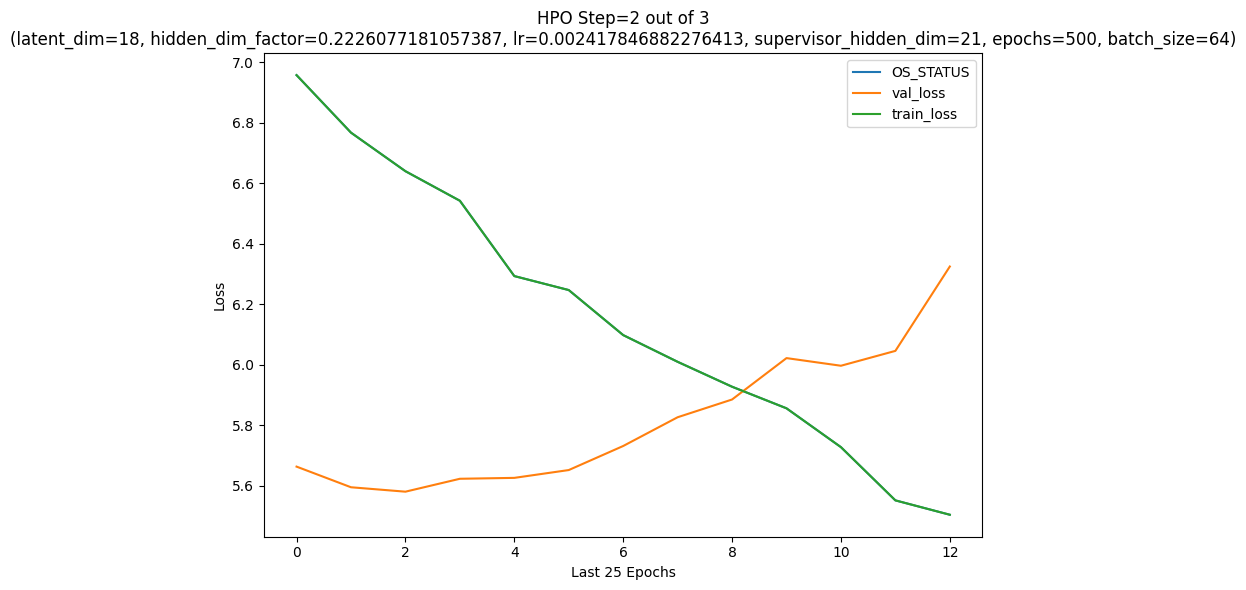

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     6.324275493621826     │
│         val_loss          │     6.324275493621826     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:09<00:04,  4.76s/it, Iteration=2, Best Loss=6.32]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 6.324275493621826; best params: {'latent_dim': 18, 'hidden_dim_factor': 0.2226077181057387, 'lr': 0.002417846882276413, 'supervisor_hidden_dim': 21, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 97, 'hidden_dim_factor': 0.42712436061273684, 'lr': 0.0005697719939974019, 'supervisor_hidden_dim': 14, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  180 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 18.9 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  1.4 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 200 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 200 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

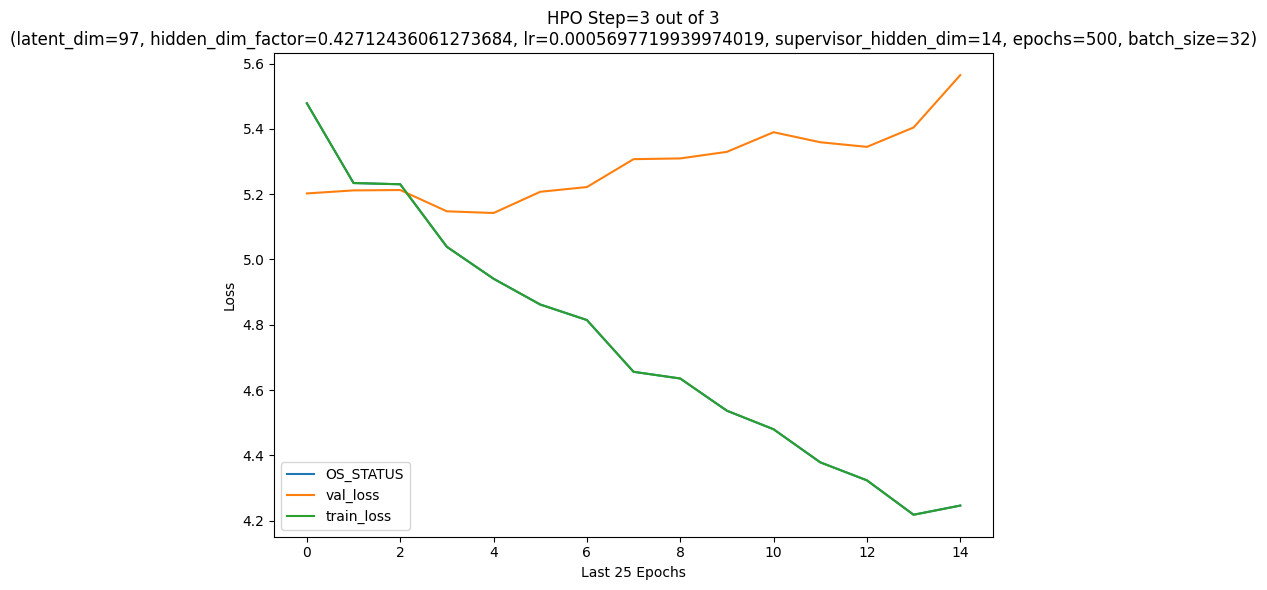

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     5.56448221206665      │
│         val_loss          │     5.56448221206665      │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:15<00:00,  5.08s/it, Iteration=3, Best Loss=5.56]

[INFO] current best val loss: 5.56448221206665; best params: {'latent_dim': 97, 'hidden_dim_factor': 0.42712436061273684, 'lr': 0.0005697719939974019, 'supervisor_hidden_dim': 14, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
Best params: {'latent_dim': 97, 'hidden_dim_factor': 0.42712436061273684, 'lr': 0.0005697719939974019, 'supervisor_hidden_dim': 14, 'epochs': 14, 'batch_size': 32}
소요 시간: 0.3분 (15초)
저장 완료: ./models/DirectPred_surv.pth


In [10]:
tuner_surv = flexynesis.main.HyperparameterTuning(
    train_dataset,
    model_class=flexynesis.models.DirectPred,
    config_name='DirectPred',
    target_variables=[],                       # 생존만 할 때는 빈 리스트 (추가 변수 예측 없음)
    surv_event_var='OS_STATUS',                # 사건 변수: 0=생존, 1=사망 (integer)
    surv_time_var='OS_MONTHS',                 # 생존 시간 변수 (연속형 숫자)

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=10,
    plot_losses=True,
    batch_variables=None,
    device_type=None,
)
_t0 = time.time()
model_surv, params_surv = tuner_surv.perform_tuning()
print("Best params:", params_surv)
_elapsed = time.time() - _t0
training_log.append({'model': 'DirectPred (생존분석)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_surv, f'./models/DirectPred_surv.pth')
print(f'저장 완료: ./models/DirectPred_surv.pth')

In [11]:
metrics_surv = flexynesis.utils.evaluate_wrapper(
    method='DirectPred_survival',
    y_pred_dict=model_surv.predict(test_dataset),
    dataset=test_dataset,
    surv_event_var=model_surv.surv_event_var,
    surv_time_var=model_surv.surv_time_var,
)
all_metrics.append(metrics_surv)
metrics_surv

,method,var,variable_type,metric,value
0,DirectPred_survival,OS_STATUS,categorical,balanced_acc,0.500000
1,DirectPred_survival,OS_STATUS,categorical,f1_score,0.450000
2,DirectPred_survival,OS_STATUS,categorical,kappa,0.000000
3,DirectPred_survival,OS_STATUS,categorical,average_auroc,0.480469
4,DirectPred_survival,OS_STATUS,categorical,average_aupr,0.550953


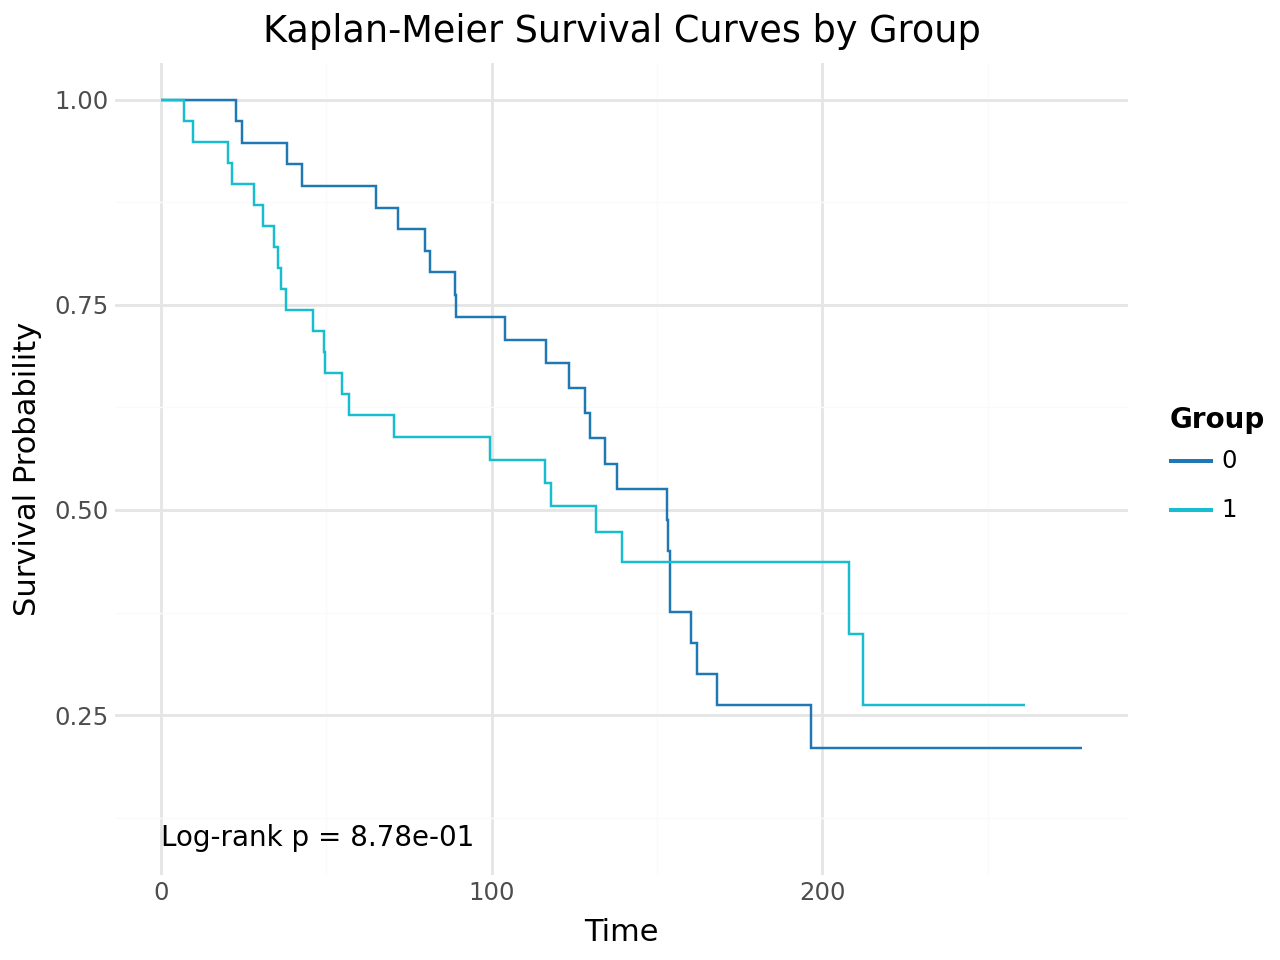

In [12]:
# risk score = exp(log-hazard): 값이 클수록 고위험
outputs = model_surv.predict(test_dataset)['OS_STATUS']
# OS_STATUS가 categorical로 인식되면 (n, 2) shape → 첫 번째 컬럼만 사용
if outputs.ndim > 1:
    outputs = outputs[:, 0]
risk_scores = np.exp(outputs.flatten())
groups = np.digitize(risk_scores, np.quantile(risk_scores, [0.5]))  # 중앙값 기준 0=Low, 1=High

durations = test_dataset.ann['OS_MONTHS'].float()
events = test_dataset.ann['OS_STATUS'].float()
valid_t = ~torch.isnan(durations) & ~torch.isnan(events)  # NaN 샘플 제거 (torch bool)
valid_np = valid_t.numpy()                                 # numpy 변환 (groups 인덱싱용)

flexynesis.utils.plot_kaplan_meier_curves(
    durations[valid_t],          # 생존 시간 벡터
    events[valid_t],             # 사건 발생 여부 벡터 (0/1)
    groups[valid_np],            # 그룹 레이블 (numpy array라 numpy bool 필요)
)

---
## Section 3. supervised_vae — 분류

**구조**: Encoder → FC_mean / FC_log_var → reparameterize → Decoder + supervisor head  
**Loss**: MMD (latent regularization) + NLL (reconstruction) + CE (supervisor)

Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 42, 'hidden_dim_factor': 0.4015102053217571, 'supervisor_hidden_dim': 23, 'lr': 0.0005203857985647049, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  165 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  3.6 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  3.6 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  152 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.2 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 325 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 325 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

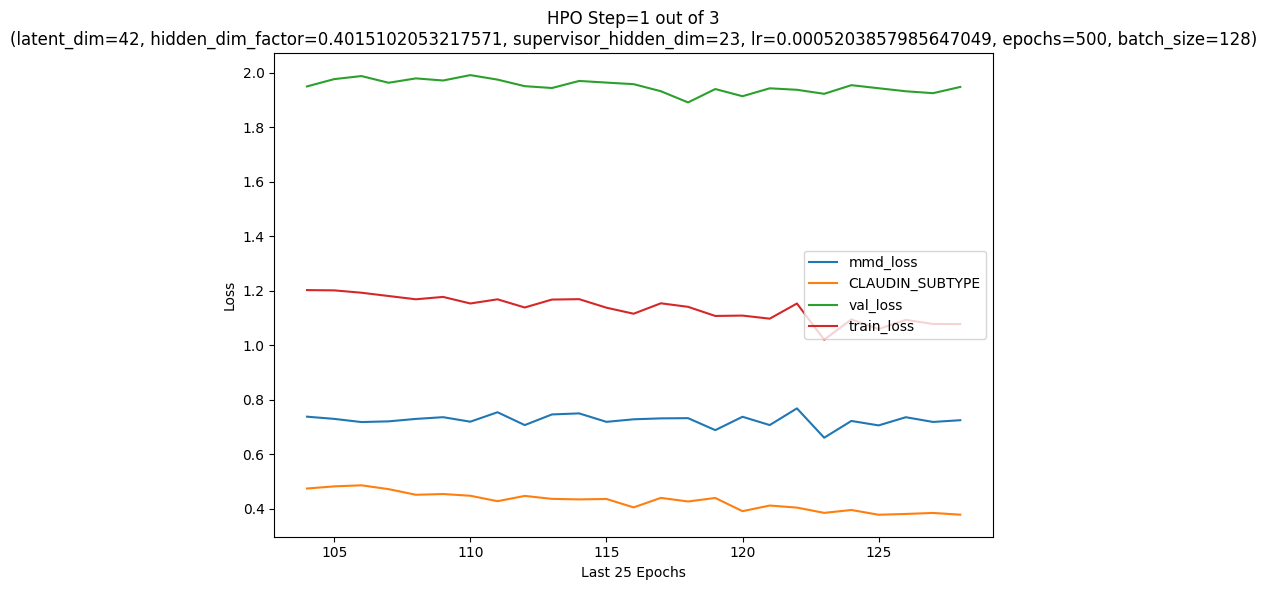

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.2416714429855347     │
│         mmd_loss          │    0.7029315829277039     │
│         val_loss          │    1.9446029663085938     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:41<01:22, 41.47s/it, Iteration=1, Best Loss=1.94]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.9446029663085938; best params: {'latent_dim': 42, 'hidden_dim_factor': 0.4015102053217571, 'supervisor_hidden_dim': 23, 'lr': 0.0005203857985647049, 'epochs': 500, 'batch_size': 128} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  200 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 11.0 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 11.0 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  174 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.7 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 399 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 399 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

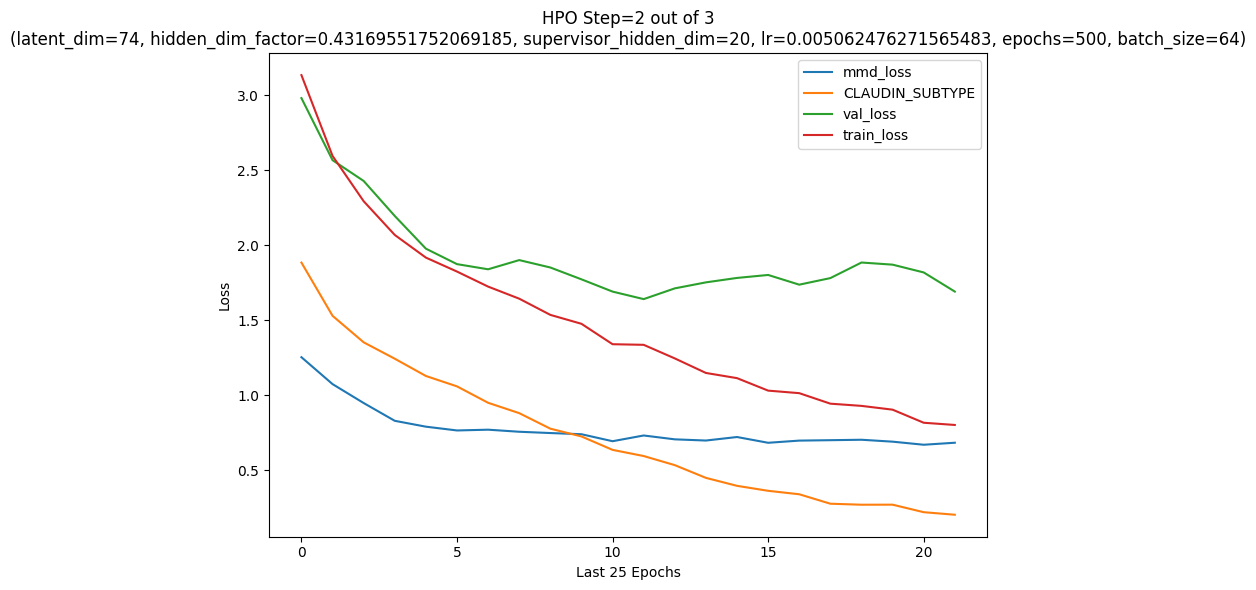

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.0014084577560425     │
│         mmd_loss          │    0.7334603071212769     │
│         val_loss          │    1.7348687648773193     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:49<00:21, 21.84s/it, Iteration=2, Best Loss=1.73]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.7348687648773193; best params: {'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 114, 'hidden_dim_factor': 0.32104485986371917, 'supervisor_hidden_dim': 11, 'lr': 0.00011417350999721898, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  170 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 26.1 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 26.1 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  140 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.4 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 364 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 364 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

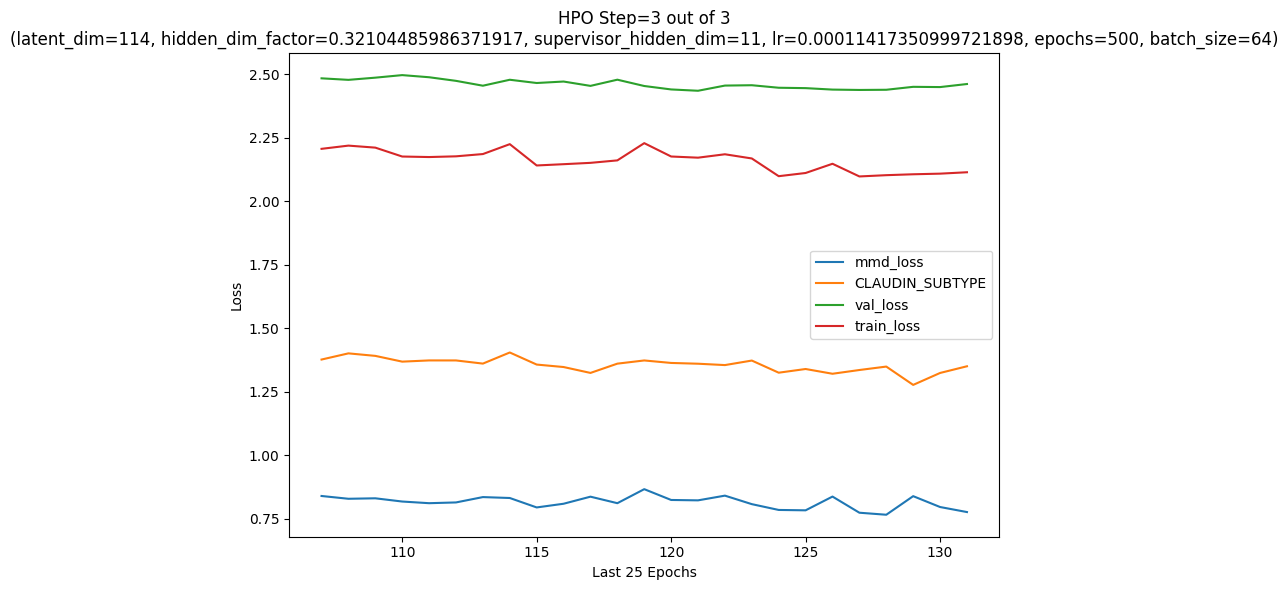

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.6210564374923706     │
│         mmd_loss          │    0.8342165946960449     │
│         val_loss          │     2.455273151397705     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:34<00:00, 31.50s/it, Iteration=3, Best Loss=1.73]

[INFO] current best val loss: 1.7348687648773193; best params: {'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64} since 1 hpo iterations
Best params: {'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 21, 'batch_size': 64}
소요 시간: 1.6분 (95초)
저장 완료: ./models/supervised_vae_clf.pth


In [13]:
tuner_vae = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.supervised_vae,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='supervised_vae',

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=10,
    plot_losses=True,
    surv_event_var=None,
    surv_time_var=None,
    batch_variables=None,
    device_type=None,
)
_t0 = time.time()
model_vae, params_vae = tuner_vae.perform_tuning()
print("Best params:", params_vae)
_elapsed = time.time() - _t0
training_log.append({'model': 'supervised_vae (분류)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_vae, f'./models/supervised_vae_clf.pth')
print(f'저장 완료: ./models/supervised_vae_clf.pth')

In [14]:
metrics_vae = flexynesis.utils.evaluate_wrapper(
    method='supervised_vae',
    y_pred_dict=model_vae.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_vae)
metrics_vae

,method,var,variable_type,metric,value
0,supervised_vae,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.593459
1,supervised_vae,CLAUDIN_SUBTYPE,categorical,f1_score,0.718927
2,supervised_vae,CLAUDIN_SUBTYPE,categorical,kappa,0.655808
3,supervised_vae,CLAUDIN_SUBTYPE,categorical,average_auroc,0.900751
4,supervised_vae,CLAUDIN_SUBTYPE,categorical,average_aupr,0.796573


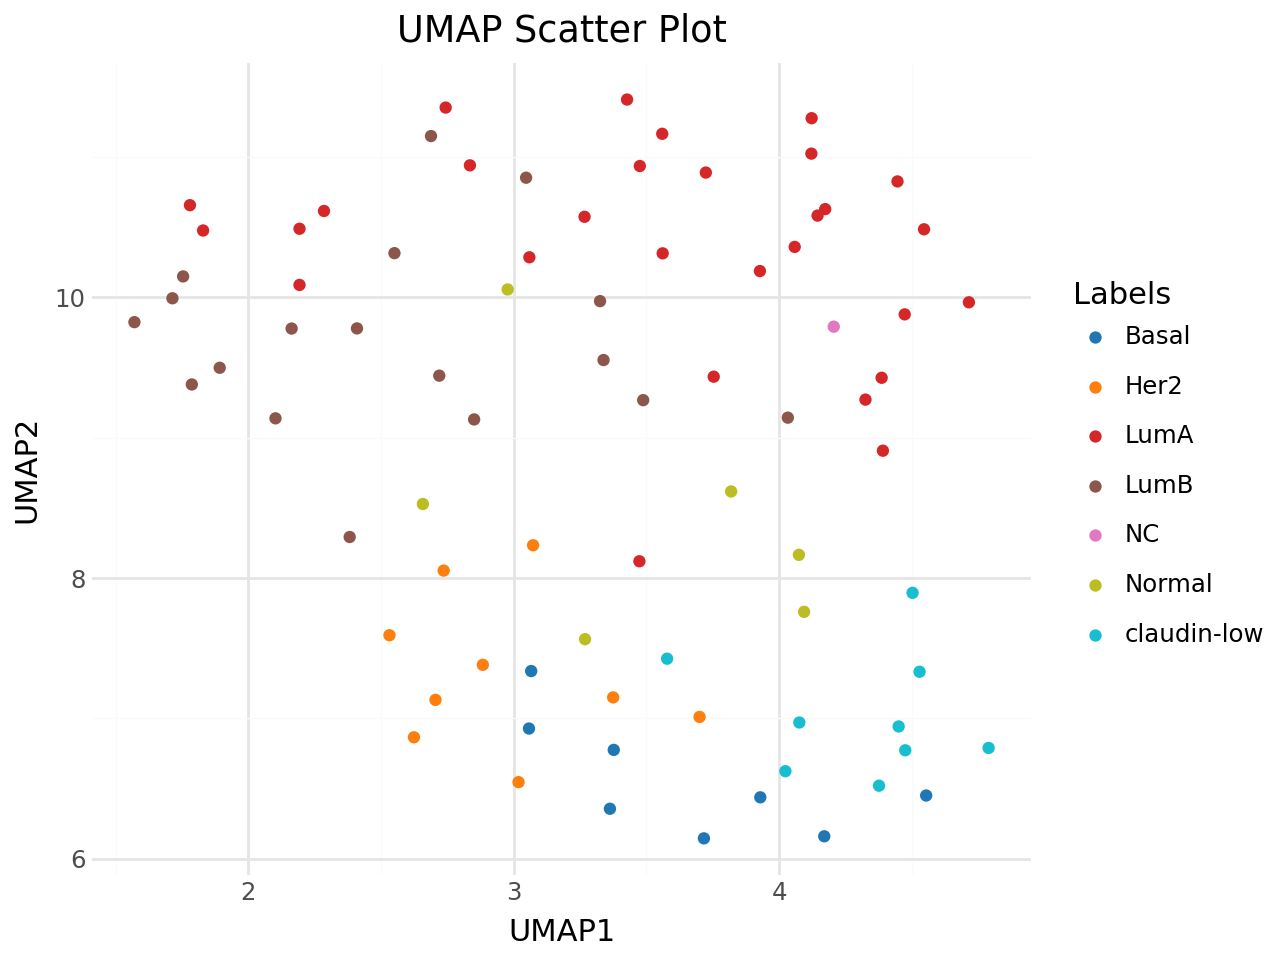

In [15]:
E_vae = model_vae.transform(test_dataset)
flexynesis.utils.plot_dim_reduced(E_vae, labels, color_type='categorical', method='umap')

---
## Section 4. supervised_vae — 비지도

`target_variables=[]` → supervisor head 없이 순수 VAE  
Louvain 클러스터링 후 CLAUDIN_SUBTYPE과 AMI/ARI 비교

Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 96.4 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  3.7 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  3.7 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 88.9 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 192 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 192 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

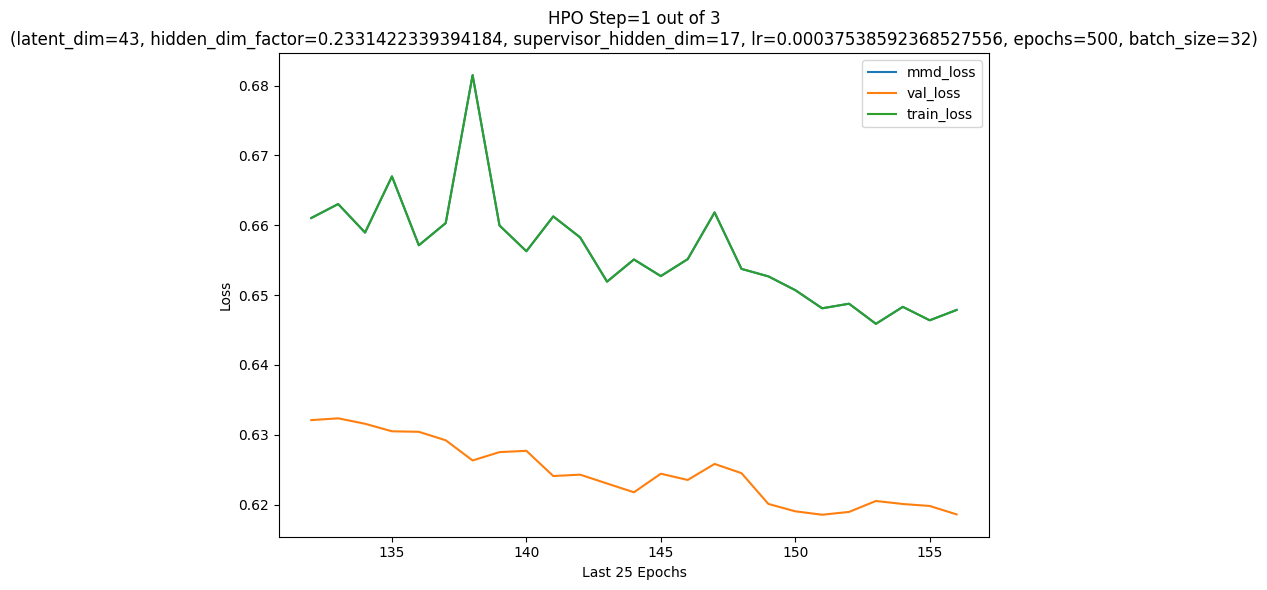

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │    0.6193145513534546     │
│         val_loss          │    0.6193145513534546     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [01:09<02:19, 69.75s/it, Iteration=1, Best Loss=0.619]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.6193145513534546; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 18, 'hidden_dim_factor': 0.49631671692080953, 'supervisor_hidden_dim': 18, 'lr': 0.0005870205355800884, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  184 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │    666 │ train │     0 │
│ 3 │ FC_log_var │ Linear        │    666 │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  178 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 364 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 364 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

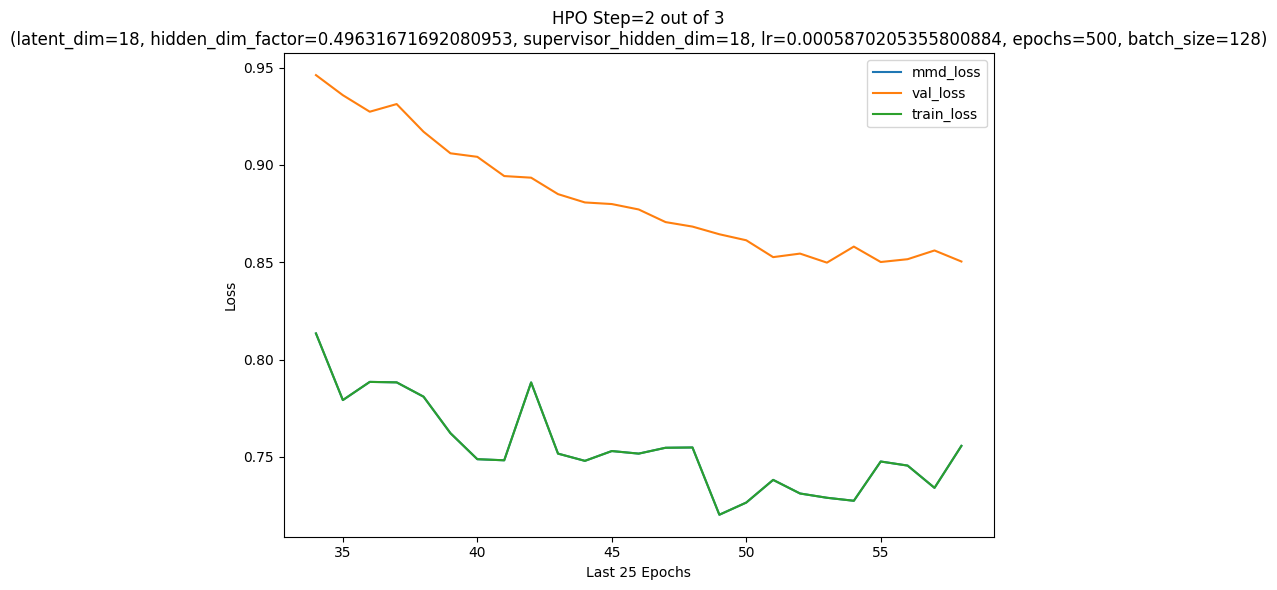

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │    0.8509323000907898     │
│         val_loss          │    0.8509323000907898     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [01:28<00:39, 39.68s/it, Iteration=2, Best Loss=0.619]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.6193145513534546; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 104, 'hidden_dim_factor': 0.22682330069367787, 'supervisor_hidden_dim': 18, 'lr': 0.005731081904472266, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  116 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 21.7 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 21.7 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 97.9 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 258 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 258 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

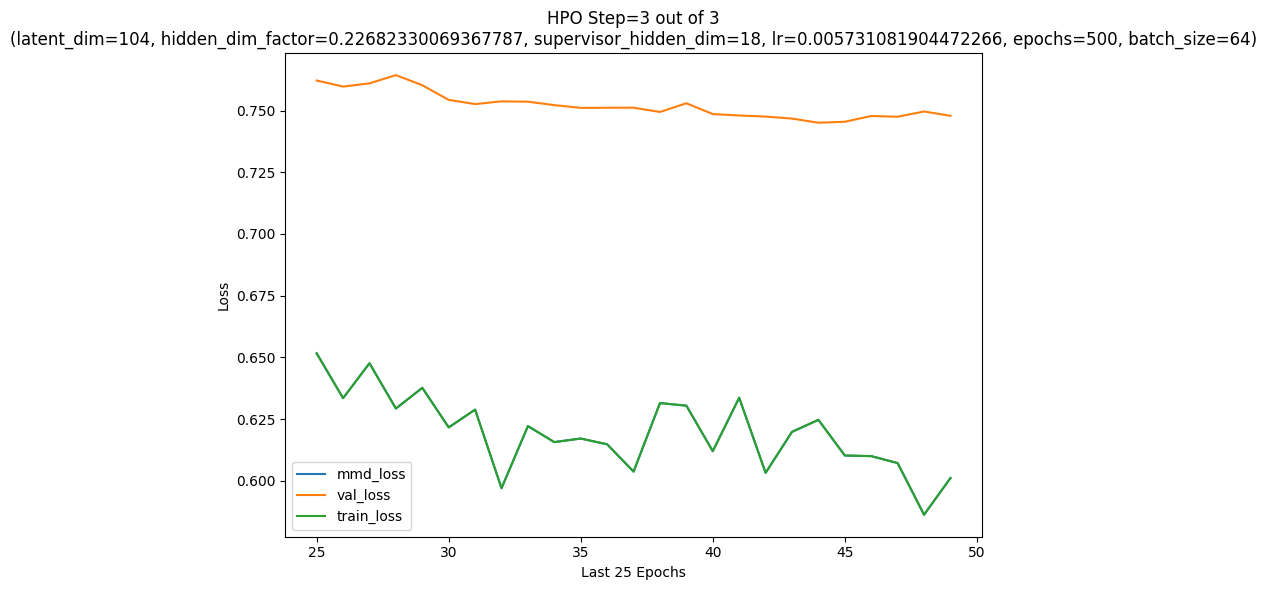

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │      0.7493896484375      │
│         val_loss          │      0.7493896484375      │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:45<00:00, 35.23s/it, Iteration=3, Best Loss=0.619]

[INFO] current best val loss: 0.6193145513534546; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 2 hpo iterations
소요 시간: 1.8분 (106초)
저장 완료: ./models/supervised_vae_unsup.pth


In [16]:
tuner_unsup = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.supervised_vae,
    target_variables=[],          # 빈 리스트 → supervisor head 없이 순수 VAE
    config_name='supervised_vae',

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=5,        # 비지도는 수렴 빠르므로 patience 짧게
    plot_losses=True,
    surv_event_var=None,
    surv_time_var=None,
    batch_variables=None,
    device_type=None,
)
_t0 = time.time()
model_unsup, _ = tuner_unsup.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'supervised_vae (비지도)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_unsup, f'./models/supervised_vae_unsup.pth')
print(f'저장 완료: ./models/supervised_vae_unsup.pth')

In [17]:
E_unsup = model_unsup.transform(test_dataset)

cluster_labels, G, partition = flexynesis.utils.louvain_clustering(
    E_unsup,          # embedding DataFrame
    k=10,             # k-NN 그래프의 이웃 수 (클수록 큰 클러스터, default: None)
    threshold=None,   # 거리 threshold로 edge 연결 (k와 둘 중 하나만 사용, None=k 방식 사용)
)
print("클러스터 수:", len(set(cluster_labels)))

scores = flexynesis.utils.compute_ami_ari(
    labels,           # 레이블 세트 1 (실제 서브타입)
    cluster_labels,   # 레이블 세트 2 (클러스터)
    # AMI=0 랜덤, 1=완벽 일치 / ARI=0 랜덤, 1=완벽 일치
)
print("AMI/ARI vs CLAUDIN_SUBTYPE:", scores)

클러스터 수: 5
AMI/ARI vs CLAUDIN_SUBTYPE: {'ami': 0.16914889091396618, 'ari': 0.10321242334587202}


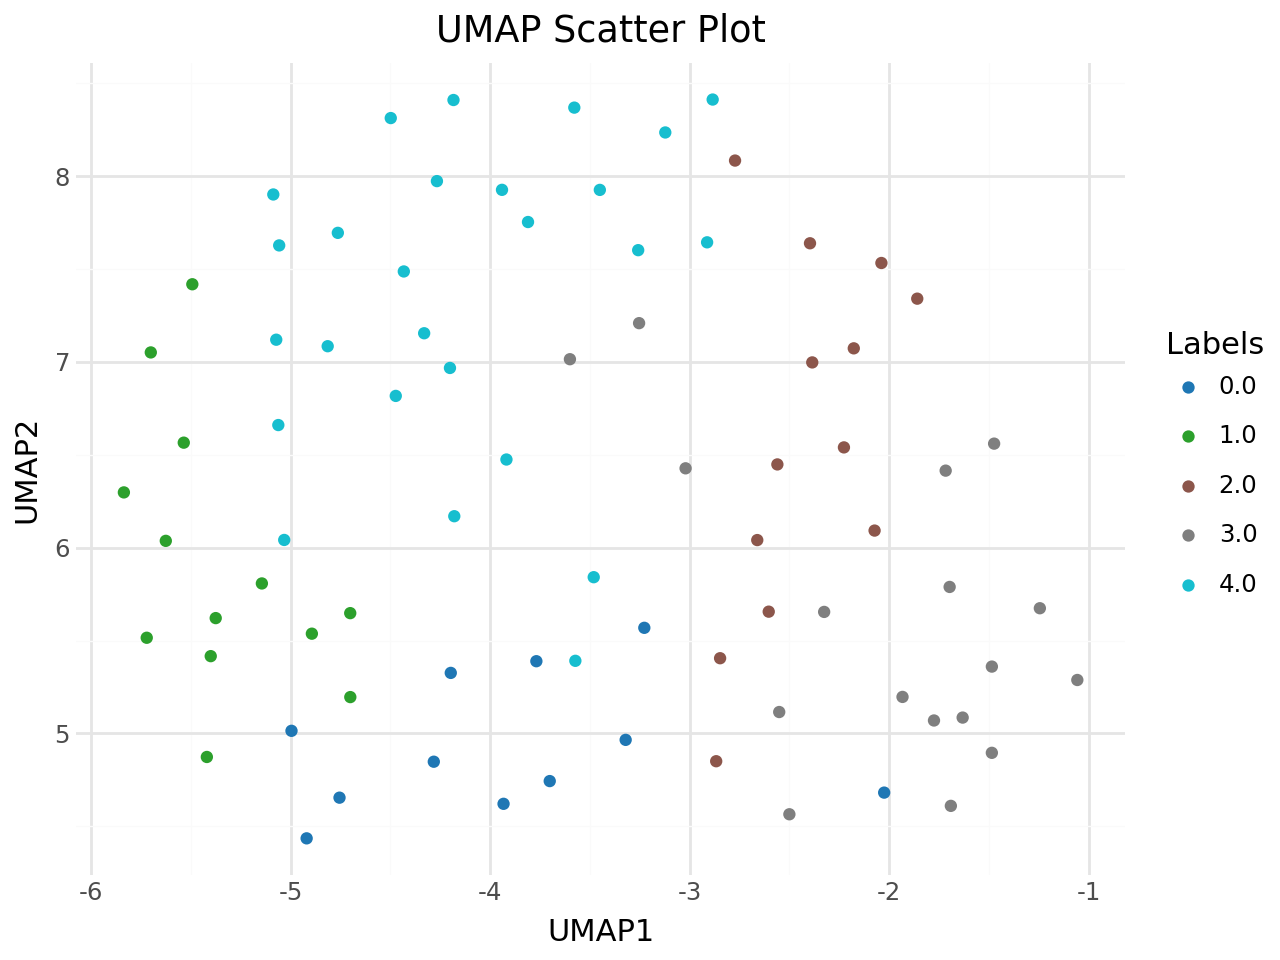

In [18]:
# 클러스터 레이블로 UMAP
flexynesis.utils.plot_dim_reduced(E_unsup, cluster_labels, color_type='categorical', method='umap')

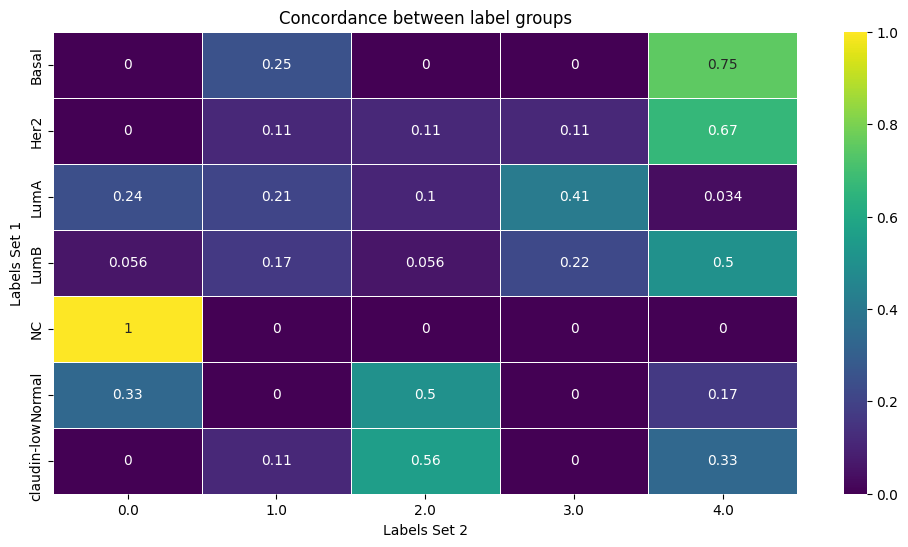

In [19]:
flexynesis.utils.plot_label_concordance_heatmap(
    labels,           # 행 레이블 (실제 서브타입)
    cluster_labels,   # 열 레이블 (클러스터 번호)
    figsize=(12, 6),  # 플롯 크기
    # 각 행(실제 레이블)이 각 클러스터에 얼마나 분포하는지 비율 (행 합=1)
)

---
## Section 5. MultiTripletNetwork — Metric Learning

**구조**: 같은 클래스 샘플(positive) vs 다른 클래스 샘플(negative) triplet 구성  
**Loss**: Triplet loss + CE (supervisor head)  
→ latent space에서 같은 서브타입끼리 가깝게, 다른 서브타입끼리 멀게 학습

In [20]:
# ── MultiTripletNetwork 진단 ─────────────────────────────────────
# 1) TripletDataset 로딩 테스트
from flexynesis.data import TripletMultiOmicDataset
from torch.utils.data import DataLoader, random_split
import time

print('TripletMultiOmicDataset 생성 중...')
t0 = time.time()
triplet_ds = TripletMultiOmicDataset(train_dataset, 'CLAUDIN_SUBTYPE')
print(f'  완료 ({time.time()-t0:.1f}s), len={len(triplet_ds)}')

# 클래스별 샘플 수 확인 (1개 클래스=infinite loop 위험)
import numpy as np
labels = train_dataset.ann['CLAUDIN_SUBTYPE'].numpy()
unique, counts = np.unique(labels, return_counts=True)
print('클래스별 샘플 수:', dict(zip(unique.tolist(), counts.tolist())))
assert all(c >= 2 for c in counts), 'ERROR: 1개짜리 클래스 있음 → infinite loop!'

# 2) DataLoader 배치 1개 로딩 테스트
print('\nDataLoader 배치 테스트...')
t0 = time.time()
loader = DataLoader(triplet_ds, batch_size=16, num_workers=0, pin_memory=False)
batch = next(iter(loader))
print(f'  완료 ({time.time()-t0:.1f}s), batch keys: anchor={list(batch[0].keys())}')
print('진단 통과! DataLoader 정상')


TripletMultiOmicDataset 생성 중...
  완료 (0.0s), len=199
클래스별 샘플 수: {0.0: 22, 1.0: 23, 2.0: 71, 3.0: 50, 4.0: 2, 5.0: 14, 6.0: 17}

DataLoader 배치 테스트...
  완료 (0.0s), batch keys: anchor=['gex', 'cna']
진단 통과! DataLoader 정상


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 124, 'hidden_dim_factor': 0.3673126478750132, 'supervisor_hidden_dim': 16, 'lr': 0.001448555708653014, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  163 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 30.9 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.2 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 196 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 196 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.
py:434: PossibleUserWarning: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve 
performance.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.
py:434: PossibleUserWarning: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve 
performance.

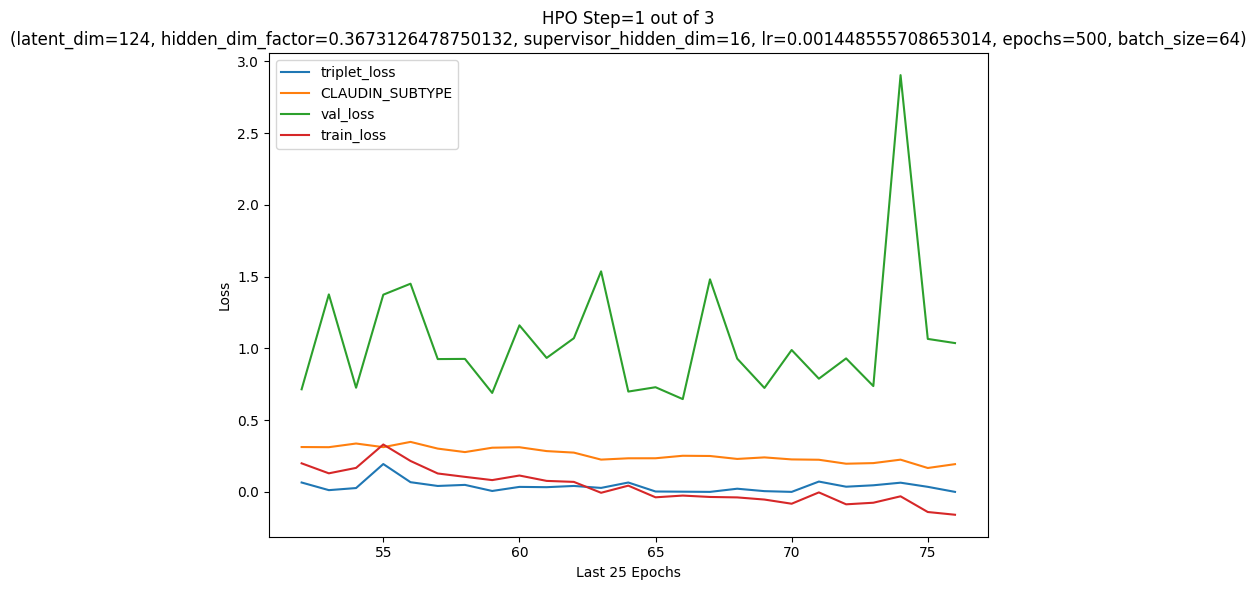

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.6612181067466736     │
│       triplet_loss        │    0.5941464304924011     │
│         val_loss          │    1.2553645372390747     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:12<00:24, 12.35s/it, Iteration=1, Best Loss=1.26]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.2553645372390747; best params: {'latent_dim': 124, 'hidden_dim_factor': 0.3673126478750132, 'supervisor_hidden_dim': 16, 'lr': 0.001448555708653014, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 72, 'hidden_dim_factor': 0.4592911047805077, 'supervisor_hidden_dim': 12, 'lr': 0.0016164943109039617, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  184 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 10.4 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │    991 │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 196 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 196 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

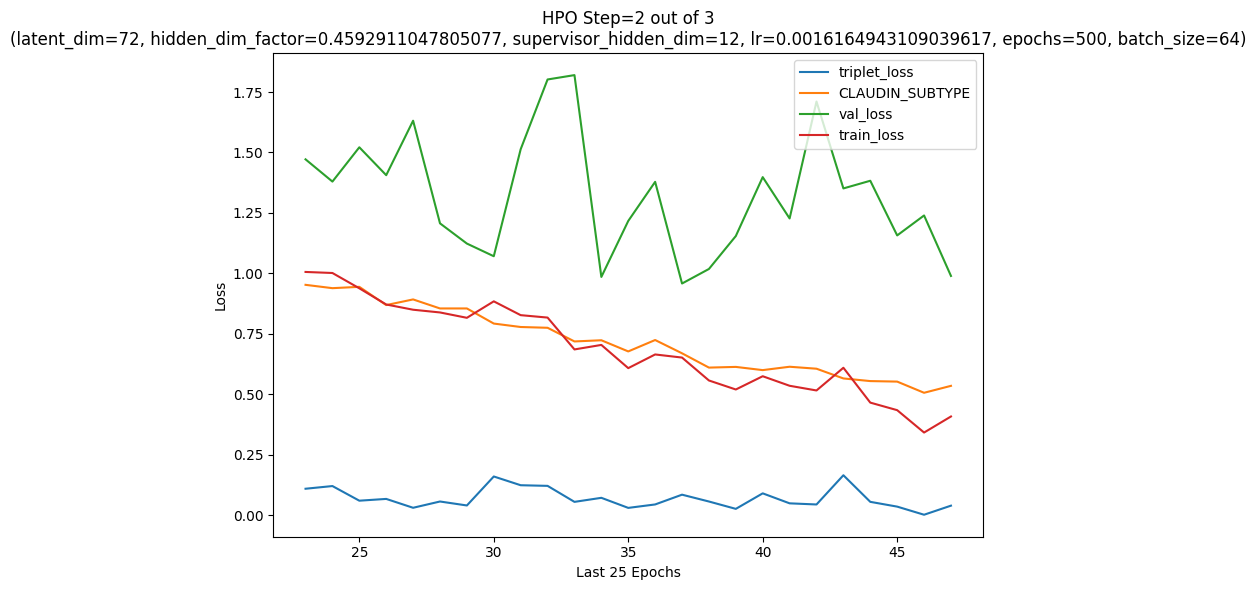

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8535866141319275     │
│       triplet_loss        │    0.33389025926589966    │
│         val_loss          │    1.1874768733978271     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:20<00:09,  9.70s/it, Iteration=2, Best Loss=1.19]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.1874768733978271; best params: {'latent_dim': 72, 'hidden_dim_factor': 0.4592911047805077, 'supervisor_hidden_dim': 12, 'lr': 0.0016164943109039617, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 83, 'hidden_dim_factor': 0.23544398683385964, 'supervisor_hidden_dim': 26, 'lr': 0.00697155294703412, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 96.8 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 13.9 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.4 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 113 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 113 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

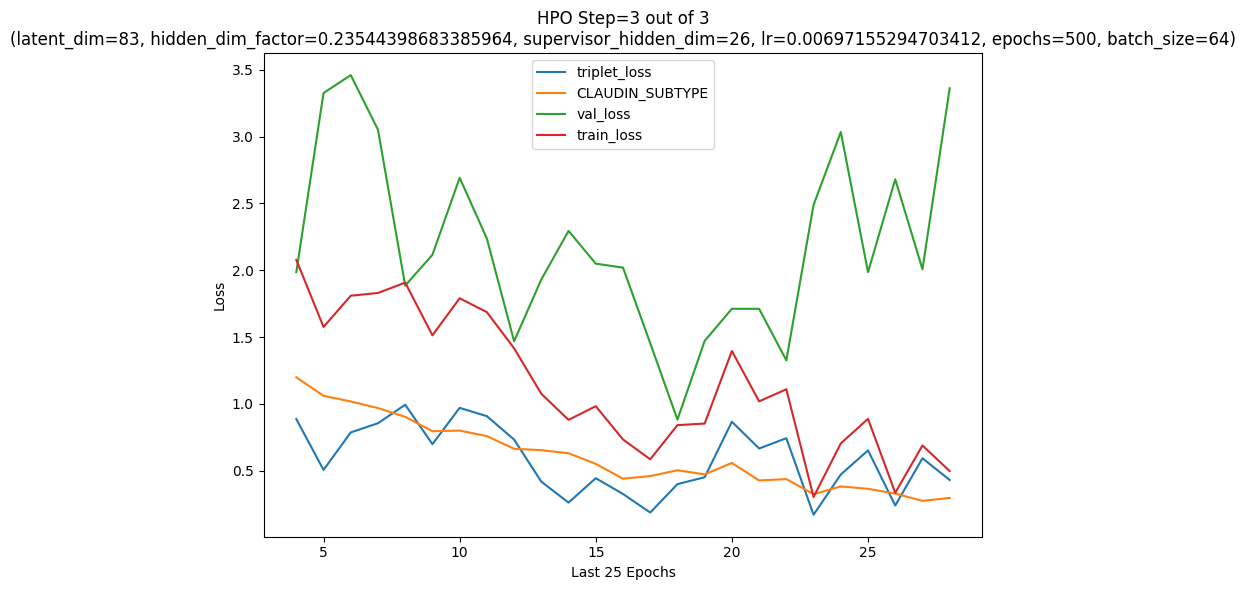

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.0909415483474731     │
│       triplet_loss        │    0.5885956883430481     │
│         val_loss          │     1.679537296295166     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:24<00:00,  8.19s/it, Iteration=3, Best Loss=1.19]

[INFO] current best val loss: 1.1874768733978271; best params: {'latent_dim': 72, 'hidden_dim_factor': 0.4592911047805077, 'supervisor_hidden_dim': 12, 'lr': 0.0016164943109039617, 'epochs': 500, 'batch_size': 64} since 1 hpo iterations
Best params: {'latent_dim': 72, 'hidden_dim_factor': 0.4592911047805077, 'supervisor_hidden_dim': 12, 'lr': 0.0016164943109039617, 'epochs': 47, 'batch_size': 64}
소요 시간: 0.4분 (25초)
저장 완료: ./models/MultiTripletNetwork_clf.pth


In [21]:
tuner_tri = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.MultiTripletNetwork,
    target_variables=['CLAUDIN_SUBTYPE'],  # triplet 구성의 기준 변수 (같은 클래스=positive)
    config_name='MultiTripletNetwork',

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=10,
    plot_losses=True,
    surv_event_var=None,
    surv_time_var=None,
    batch_variables=None,
    device_type=None,
    num_workers=0,             # Jupyter에서 persistent_workers deadlock 방지
)
_t0 = time.time()
model_tri, params_tri = tuner_tri.perform_tuning()
print("Best params:", params_tri)
_elapsed = time.time() - _t0
training_log.append({'model': 'MultiTripletNetwork (분류)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_tri, f'./models/MultiTripletNetwork_clf.pth')
print(f'저장 완료: ./models/MultiTripletNetwork_clf.pth')

In [22]:
metrics_tri = flexynesis.utils.evaluate_wrapper(
    method='MultiTripletNetwork',
    y_pred_dict=model_tri.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_tri)
metrics_tri

,method,var,variable_type,metric,value
0,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.523878
1,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,f1_score,0.682997
2,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,kappa,0.601329
3,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,average_auroc,0.958794
4,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,average_aupr,0.846374


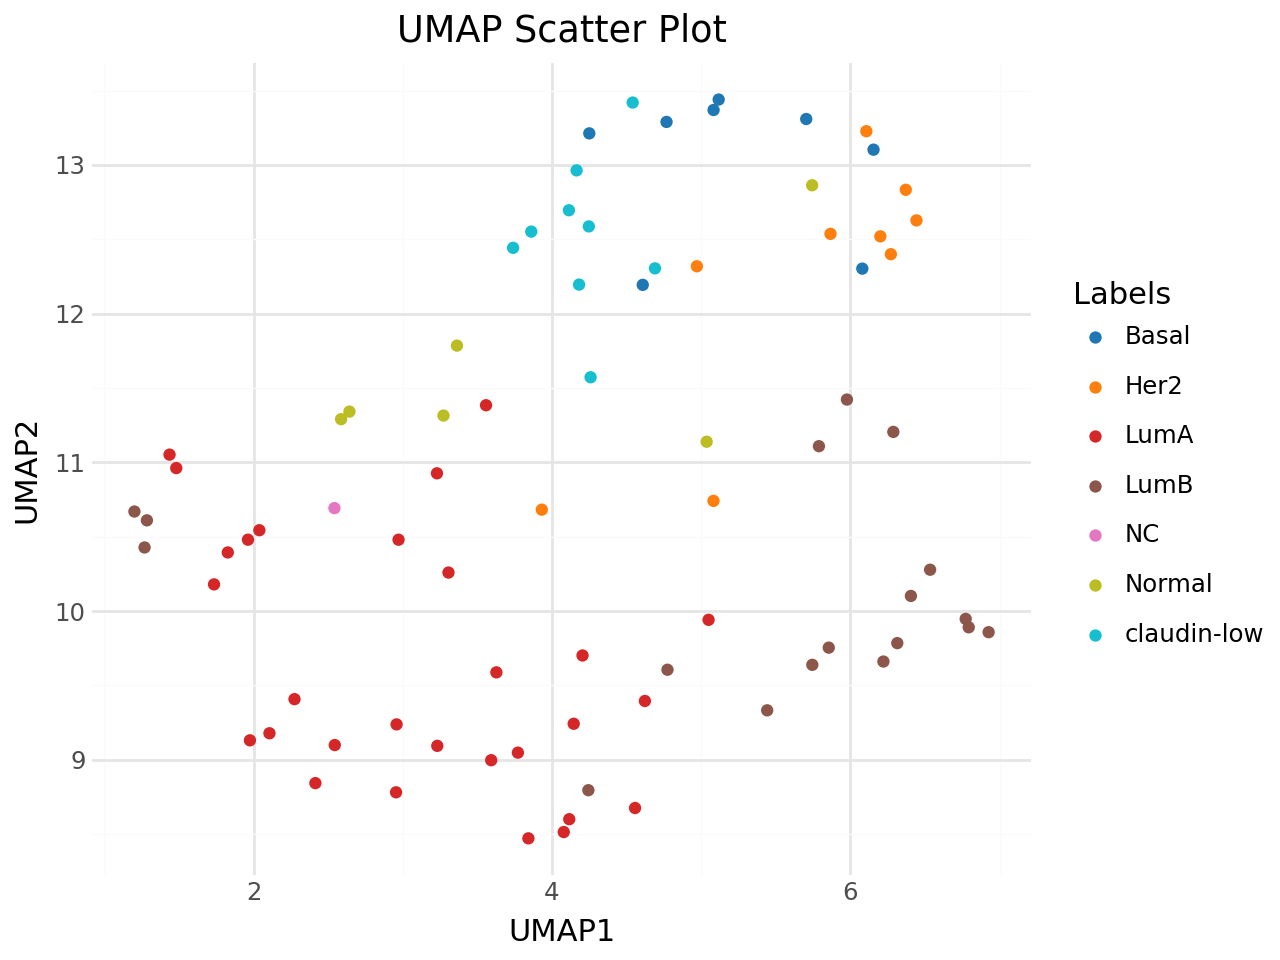

In [23]:
E_tri = model_tri.transform(test_dataset)
labels_tri = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x] for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_tri, labels_tri, color_type='categorical', method='umap')


---
## Section 6. GNN — Graph Neural Network

**구조**: STRING DB 단백질 상호작용 네트워크 기반 Graph Convolution  
**데이터**: gex만 사용 (gene → protein node)  
STRING DB 파일이 `brca_metabric_processed/` 에 포함돼 있음

In [24]:
# GNN은 gex 단일 모달리티 + STRING DB 필요
from flexynesis.data import STRING, MultiOmicDatasetNW

data_importer_gnn = flexynesis.data.DataImporter(
    path=PATH,
    data_types=['gex'],                # GNN은 gex만 (gene → protein node로 매핑)
    concatenate=False,
    top_percentile=10,
    min_features=50,
    correlation_threshold=0.9,
    variance_threshold=0.8,
    na_threshold=0.1,
    log_transform=False,
    covariates=None,
    downsample=0,
    restrict_to_features=None,
)
train_gnn_raw, test_gnn_raw = data_importer_gnn.import_data()



[INFO] ================= Importing Data =================
[INFO] Validating data folders...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing ./brca_mini/train/clin.csv...
[INFO] Importing ./brca_mini/train/gex.csv...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing ./brca_mini/test/clin.csv...
[INFO] Importing ./brca_mini/test/gex.csv...

[INFO] ----------------- Checking for problems with the input data ----------------- 
[INFO] Data structure is valid with no errors or warnings.

[INFO] ----------------- Processing Data (train) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Imputing NA values to median of features, affected # of cells in the matrix 2  # of rows: 2
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.
[INFO] DataFrame gex - Removed 0 samples (0.00%).
[INFO] Implementing feature selection using laplacian score for layer: g

Filtering redundant features: 100%|██████████| 412/412 [00:00<00:00, 9688.95it/s]


[INFO] ----------------- Processing Data (test) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.
[INFO] DataFrame gex - Removed 0 samples (0.00%).

[INFO] ----------------- Harmonizing Data Sets ----------------- 

[INFO] ----------------- Finished Harmonizing ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 
[INFO] Training Data Stats:  {'feature_count in: gex': 369, 'sample_count': 200}
[INFO] Test Data Stats:  {'feature_count in: gex': 369, 'sample_count': 80}
[INFO] Merging Feature Logs...
[INFO] Data import successful.


In [25]:
# STRING DB 자동 다운로드 & 캐시 (~/.cache/flexynesis/STRING/)
# 첫 실행 시 다운로드 시간 필요, 이후엔 캐시 사용
print("STRING DB 로딩 중...")
string_obj = STRING(organism=9606, node_name='gene_name')
graph_df = string_obj.graph_df
print(f"PPI interactions: {len(graph_df)}")

# MultiOmicDatasetNW로 래핑 (graph 정보 포함한 GNN용 dataset)
train_gnn = MultiOmicDatasetNW(train_gnn_raw, graph_df, modality_order=['gex'])
test_gnn  = MultiOmicDatasetNW(test_gnn_raw,  graph_df, modality_order=['gex'])
train_gnn.print_stats()


STRING DB 로딩 중...
PPI interactions: 95229
Dataset Statistics:
Number of nodes: 354
Total number of edges: 134
Number of node features per node: 1
Number of singletons (nodes with no edges): 225
Mean number of edges per node (excluding singletons): 2.08
Median number of edges per node (excluding singletons): 2
Max number of edges per node: 11


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 41, 'node_embedding_dim': 7, 'num_convs': 3, 'lr': 0.0028519159371770734, 'supervisor_hidden_dim': 15, 'epochs': 500, 'activation': 'relu', 'batch_size': 64}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  101 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │    772 │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

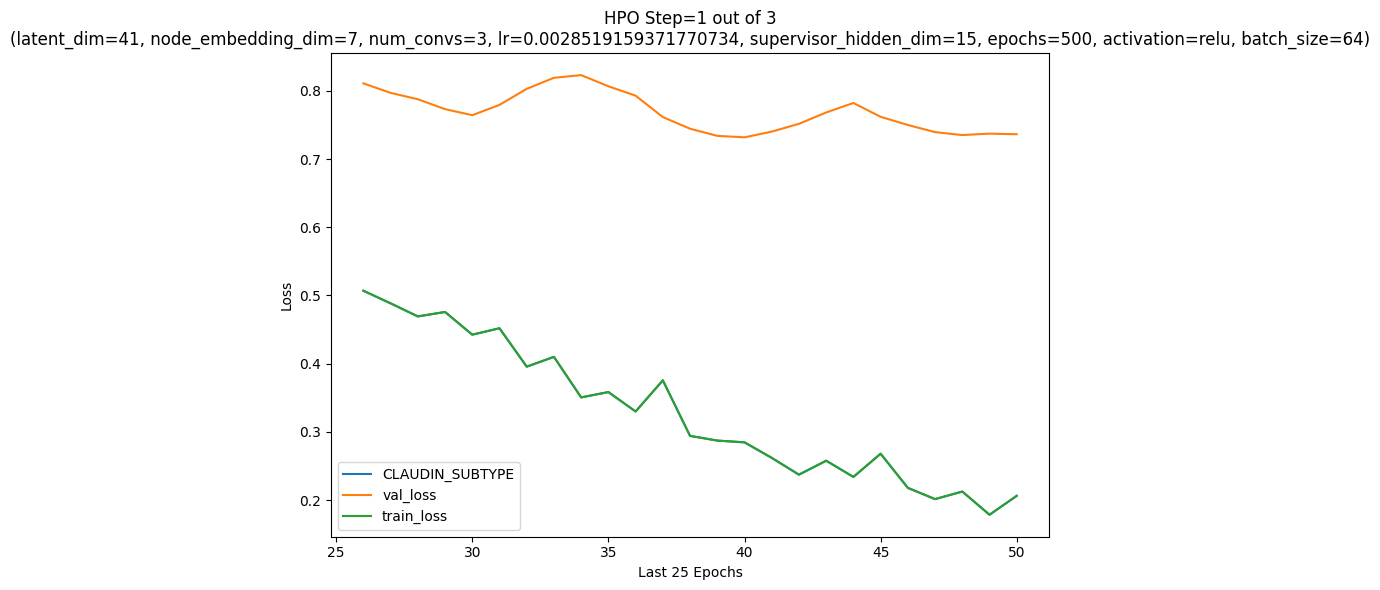

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.7364951968193054     │
│         val_loss          │    0.7364951968193054     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:12<00:25, 12.66s/it, Iteration=1, Best Loss=0.736]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.7364951968193054; best params: {'latent_dim': 41, 'node_embedding_dim': 7, 'num_convs': 3, 'lr': 0.0028519159371770734, 'supervisor_hidden_dim': 15, 'epochs': 500, 'activation': 'relu', 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 77, 'node_embedding_dim': 6, 'num_convs': 4, 'lr': 0.000571941561416394, 'supervisor_hidden_dim': 13, 'epochs': 500, 'activation': 'relu', 'batch_size': 64}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  163 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │  1.1 K │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 165 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 165 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

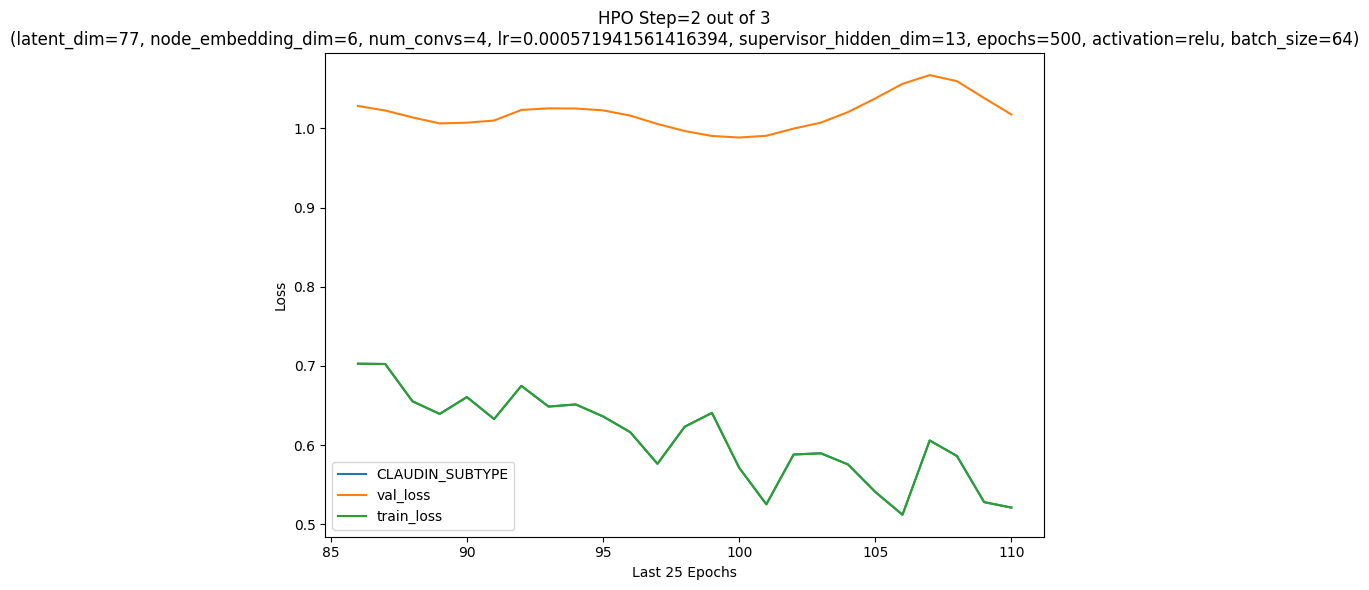

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.0175262689590454     │
│         val_loss          │    1.0175262689590454     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:47<00:25, 25.90s/it, Iteration=2, Best Loss=0.736]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.7364951968193054; best params: {'latent_dim': 41, 'node_embedding_dim': 7, 'num_convs': 3, 'lr': 0.0028519159371770734, 'supervisor_hidden_dim': 15, 'epochs': 500, 'activation': 'relu', 'batch_size': 64} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 79, 'node_embedding_dim': 12, 'num_convs': 3, 'lr': 0.000730242269877518, 'supervisor_hidden_dim': 10, 'epochs': 500, 'activation': 'relu', 'batch_size': 128}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  336 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │    897 │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 337 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 337 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

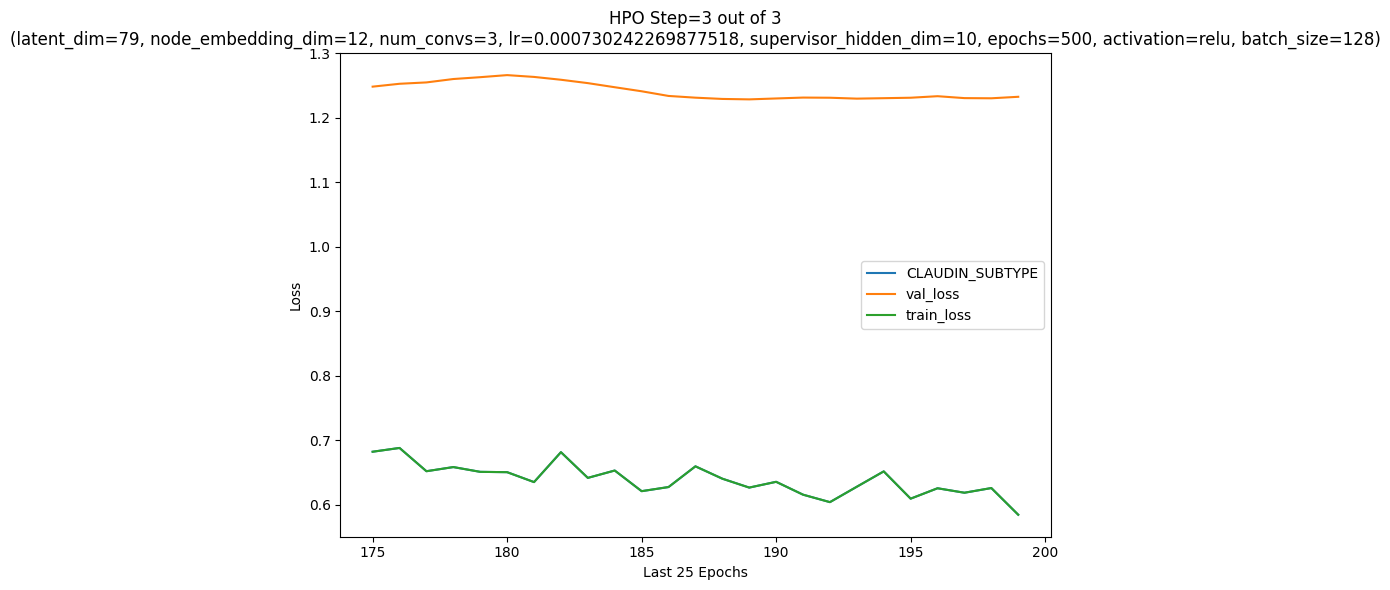

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.2328436374664307     │
│         val_loss          │    1.2328436374664307     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:48<00:00, 36.09s/it, Iteration=3, Best Loss=0.736]

[INFO] current best val loss: 0.7364951968193054; best params: {'latent_dim': 41, 'node_embedding_dim': 7, 'num_convs': 3, 'lr': 0.0028519159371770734, 'supervisor_hidden_dim': 15, 'epochs': 500, 'activation': 'relu', 'batch_size': 64} since 2 hpo iterations
Best params: {'latent_dim': 41, 'node_embedding_dim': 7, 'num_convs': 3, 'lr': 0.0028519159371770734, 'supervisor_hidden_dim': 15, 'epochs': 50, 'activation': 'relu', 'batch_size': 64}
소요 시간: 1.8분 (108초)
저장 완료: ./models/GNN_clf.pth


In [26]:
tuner_gnn = flexynesis.main.HyperparameterTuning(
    dataset=train_gnn,
    model_class=flexynesis.models.GNN,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='GNN',

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=10,
    plot_losses=True,
    surv_event_var=None,
    surv_time_var=None,
    batch_variables=None,
    device_type=None,

    # --- GNN 전용 ---
    gnn_conv_type='GC',           # 'GC'(기본), 'GCN', 'GAT', 'SAGE' 중 선택
)
_t0 = time.time()
model_gnn, params_gnn = tuner_gnn.perform_tuning()
print("Best params:", params_gnn)
_elapsed = time.time() - _t0
training_log.append({'model': 'GNN (분류)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')

os.makedirs('./models', exist_ok=True)
torch.save(model_gnn, f'./models/GNN_clf.pth')
print(f'저장 완료: ./models/GNN_clf.pth')

In [27]:
metrics_gnn = flexynesis.utils.evaluate_wrapper(
    method='GNN',
    y_pred_dict=model_gnn.predict(test_gnn),
    dataset=test_gnn,
)
all_metrics.append(metrics_gnn)
metrics_gnn

,method,var,variable_type,metric,value
0,GNN,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.508279
1,GNN,CLAUDIN_SUBTYPE,categorical,f1_score,0.616898
2,GNN,CLAUDIN_SUBTYPE,categorical,kappa,0.499091
3,GNN,CLAUDIN_SUBTYPE,categorical,average_auroc,0.907816
4,GNN,CLAUDIN_SUBTYPE,categorical,average_aupr,0.757394


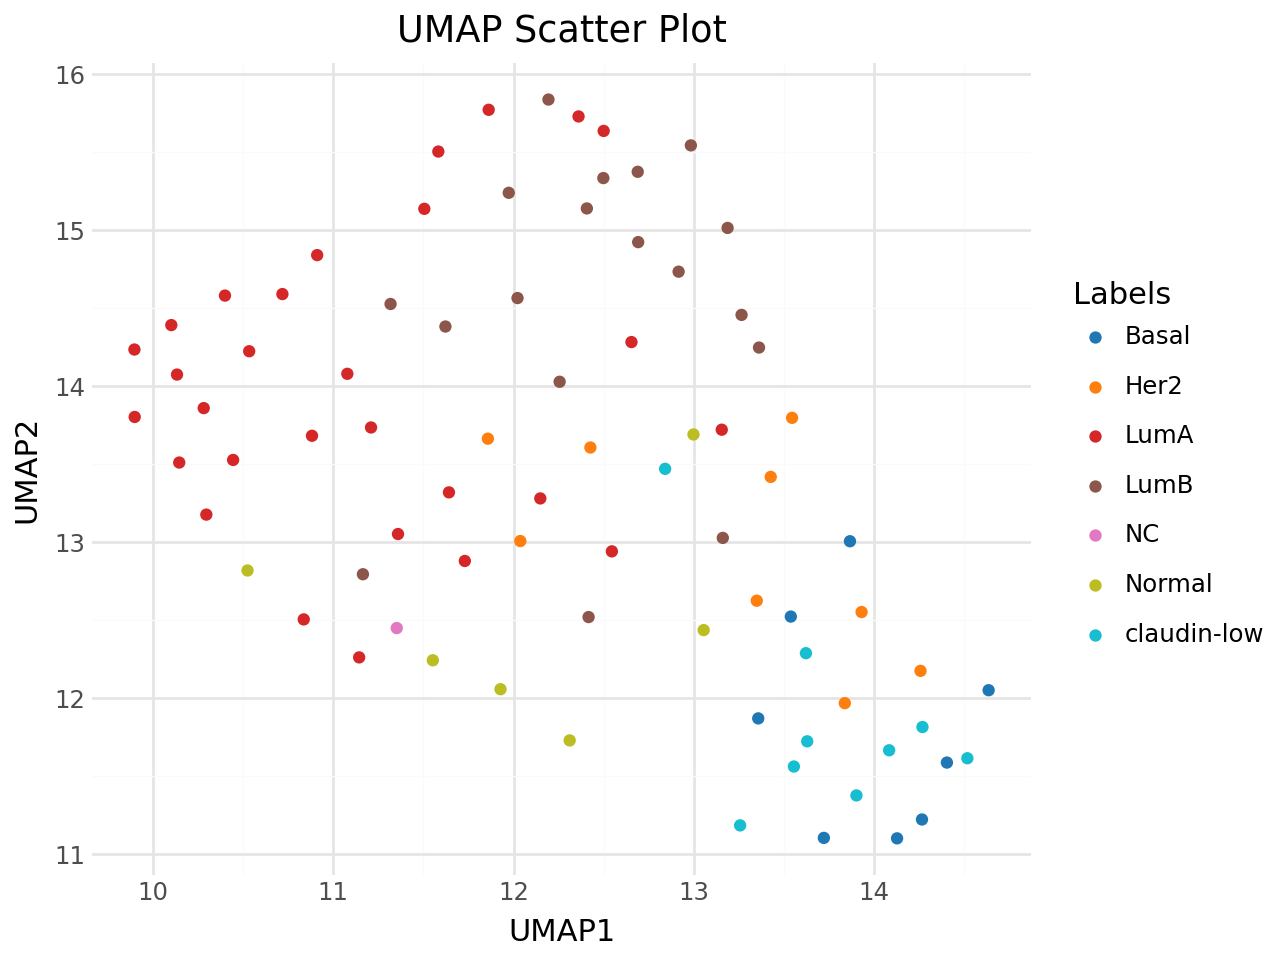

In [28]:
E_gnn = model_gnn.transform(test_gnn)
labels_gnn = [test_gnn.label_mappings['CLAUDIN_SUBTYPE'][x] for x in test_gnn.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_gnn, labels_gnn, color_type='categorical', method='umap')

---
## Section 7. CrossModalPred — Cross-Modal Prediction

**구조**: input_layers → VAE encoders → latent → decoders (output_layers) + supervisor head  
**핵심**: `input_layers`와 `output_layers`를 다르게 지정 → 한 omics로 다른 omics 예측  
- `input_layers=['gex']`, `output_layers=['cna']` → gex로 cna 재구성  
- `input_layers == output_layers` → autoencoder처럼 동작  
**Loss**: MMD (latent) + NLL (reconstruction) + CE (supervisor)

Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 102, 'hidden_dim_factor': 0.25544383777949675, 'supervisor_hidden_dim': 13, 'lr': 0.0003443082413215302, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 54.5 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 10.5 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 10.5 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 64.4 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.5 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 141 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 141 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

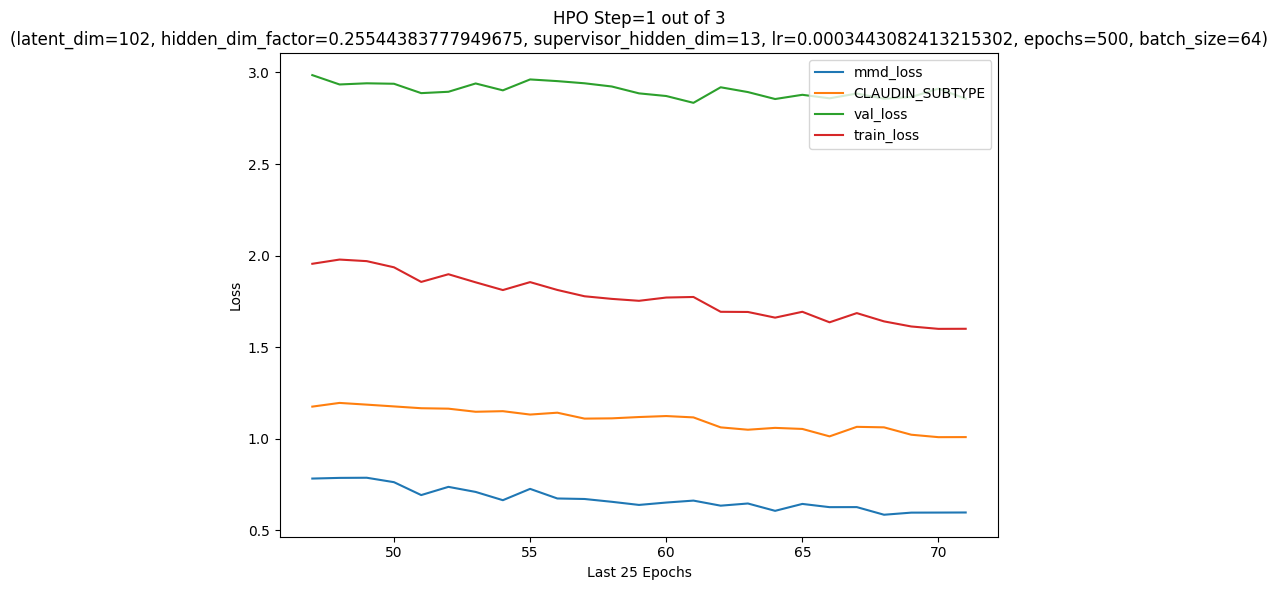

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.5806337594985962     │
│         mmd_loss          │     1.265005111694336     │
│         val_loss          │    2.8456387519836426     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:16<00:33, 16.96s/it, Iteration=1, Best Loss=2.85]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 2.8456387519836426; best params: {'latent_dim': 102, 'hidden_dim_factor': 0.25544383777949675, 'supervisor_hidden_dim': 13, 'lr': 0.0003443082413215302, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 36, 'hidden_dim_factor': 0.3374774078478793, 'supervisor_hidden_dim': 31, 'lr': 0.0029140806223627116, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 55.8 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  1.3 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  1.3 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 74.9 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.4 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 134 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 134 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

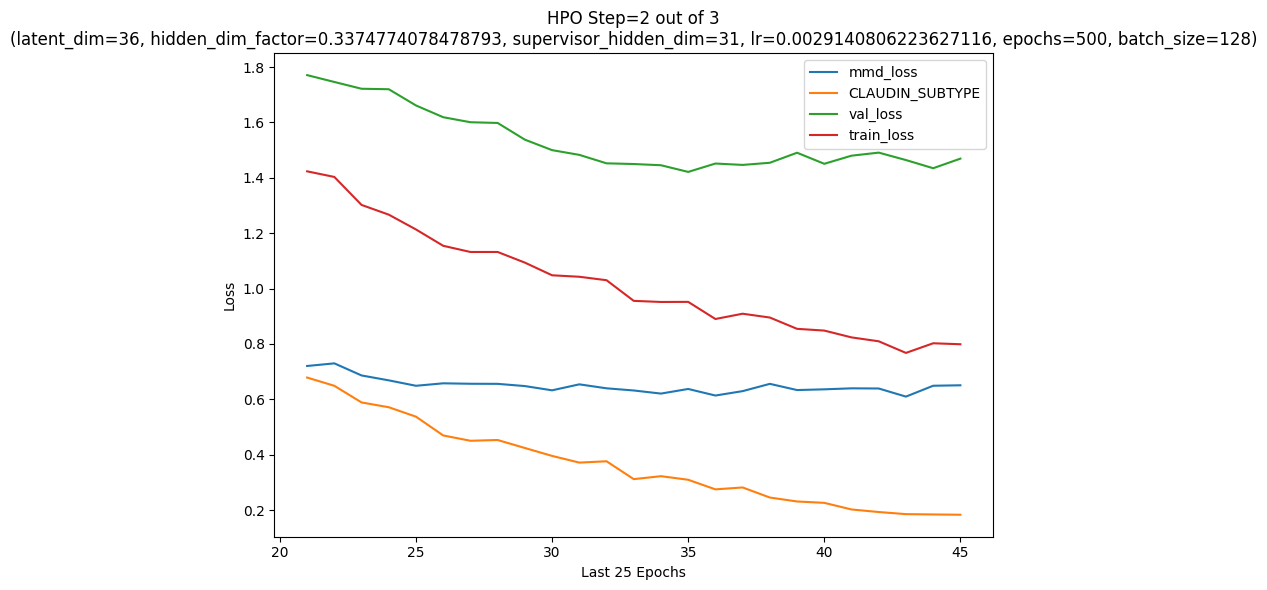

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.7386191487312317     │
│         mmd_loss          │    0.7641282081604004     │
│         val_loss          │    1.5027472972869873     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:31<00:15, 15.78s/it, Iteration=2, Best Loss=1.5] GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.5027472972869873; best params: {'latent_dim': 36, 'hidden_dim_factor': 0.3374774078478793, 'supervisor_hidden_dim': 31, 'lr': 0.0029140806223627116, 'epochs': 500, 'batch_size': 128} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 97, 'hidden_dim_factor': 0.4489759411775175, 'supervisor_hidden_dim': 25, 'lr': 0.0013637458993481124, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 94.5 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  9.5 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  9.5 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  111 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  2.7 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 227 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 227 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

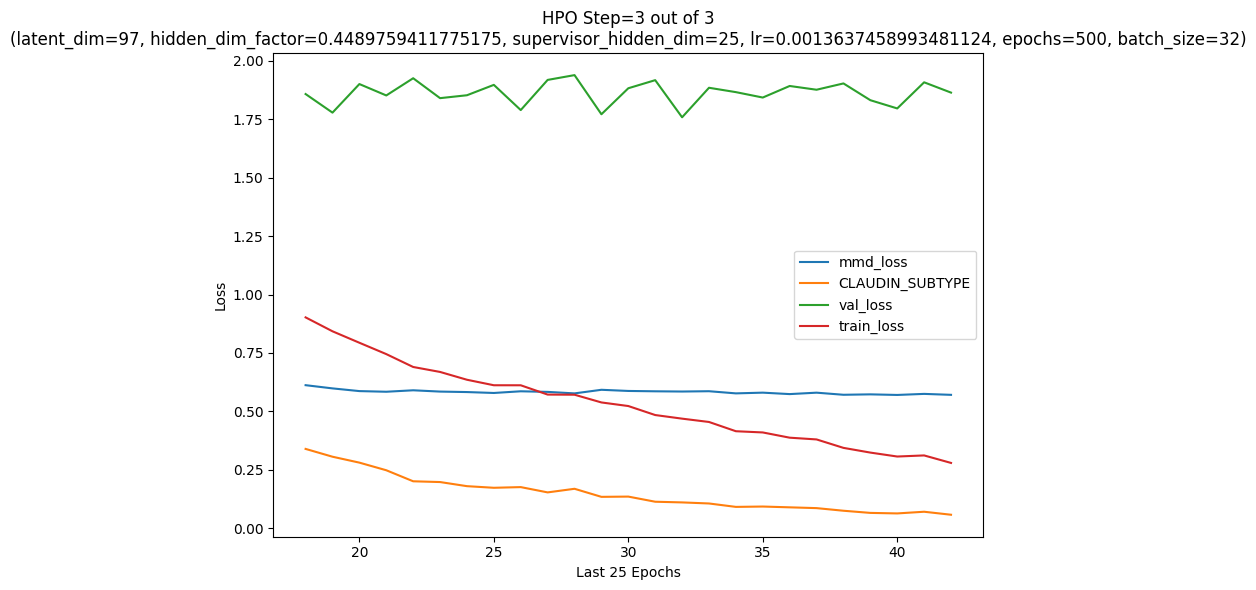

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.7819002270698547     │
│         mmd_loss          │     1.024790644645691     │
│         val_loss          │    1.8066909313201904     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:51<00:00, 17.16s/it, Iteration=3, Best Loss=1.5]

[INFO] current best val loss: 1.5027472972869873; best params: {'latent_dim': 36, 'hidden_dim_factor': 0.3374774078478793, 'supervisor_hidden_dim': 31, 'lr': 0.0029140806223627116, 'epochs': 500, 'batch_size': 128} since 1 hpo iterations
Best params: {'latent_dim': 36, 'hidden_dim_factor': 0.3374774078478793, 'supervisor_hidden_dim': 31, 'lr': 0.0029140806223627116, 'epochs': 45, 'batch_size': 128}
소요 시간: 0.9분 (51초)
저장 완료: ./models/CrossModalPred_clf.pth


In [29]:
tuner_cross = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.CrossModalPred,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='CrossModalPred',

    # --- CrossModalPred 전용 ---
    input_layers=['gex'],     # 입력으로 사용할 omics 레이어
    output_layers=['cna'],    # 재구성(decode) 대상 omics 레이어 (input과 다르면 cross-modal)

    # --- HPO 설정 ---
    n_iter=HPO_ITER,
    config_path=None,
    val_size=0.2,
    use_cv=False,
    cv_splits=5,

    # --- 학습 설정 ---
    use_loss_weighting=True,
    early_stop_patience=10,
    plot_losses=True,
    surv_event_var=None,
    surv_time_var=None,
    batch_variables=None,
    device_type=None,
)
_t0 = time.time()
model_cross, params_cross = tuner_cross.perform_tuning()
print('Best params:', params_cross)
_elapsed = time.time() - _t0
training_log.append({'model': 'CrossModalPred (분류)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f'소요 시간: {_elapsed/60:.1f}분 ({_elapsed:.0f}초)')
os.makedirs('./models', exist_ok=True)
torch.save(model_cross, f'./models/CrossModalPred_clf.pth')
print(f'저장 완료: ./models/CrossModalPred_clf.pth')

In [30]:
metrics_cross = flexynesis.utils.evaluate_wrapper(
    method='CrossModalPred',
    y_pred_dict=model_cross.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_cross)
metrics_cross

,method,var,variable_type,metric,value
0,CrossModalPred,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.586549
1,CrossModalPred,CLAUDIN_SUBTYPE,categorical,f1_score,0.708443
2,CrossModalPred,CLAUDIN_SUBTYPE,categorical,kappa,0.627455
3,CrossModalPred,CLAUDIN_SUBTYPE,categorical,average_auroc,0.922769
4,CrossModalPred,CLAUDIN_SUBTYPE,categorical,average_aupr,0.773932


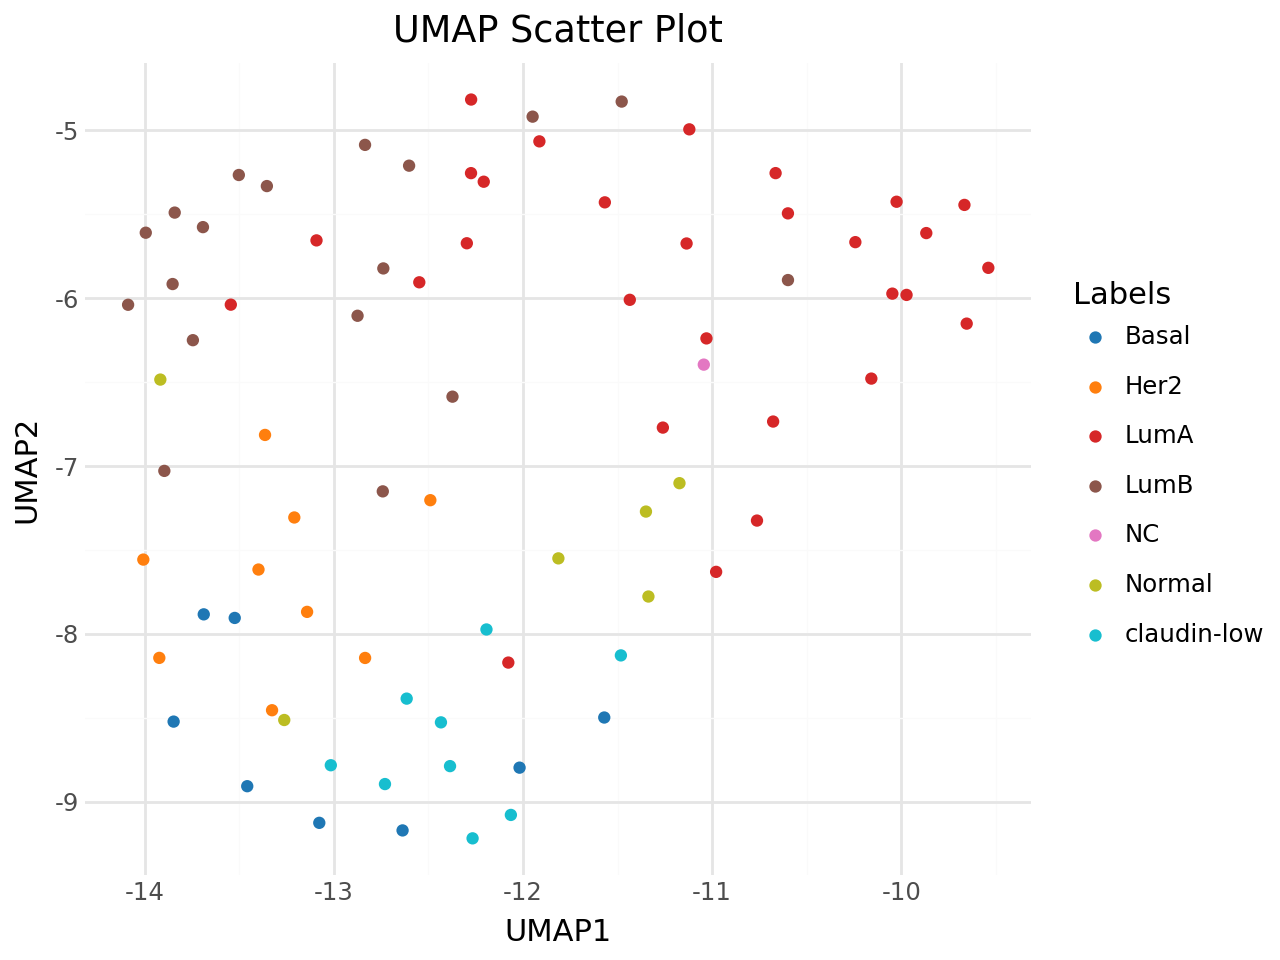

In [32]:
E_cross = model_cross.transform(test_dataset)
labels_cross = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x] for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_cross, labels_cross, color_type='categorical', method='umap')

---
## Section 8. 모델 성능 비교

분류 태스크 (`CLAUDIN_SUBTYPE`) 기준 모델 비교

In [33]:
# 학습 시간 요약
log_df = pd.DataFrame(training_log)
log_df['time_min'] = (log_df['time_sec'] / 60).round(1)
log_df['time_sec'] = log_df['time_sec'].round(0).astype(int)
log_df = log_df[['model', 'hpo_iter', 'time_min', 'time_sec']]
log_df.columns = ['모델', 'HPO iter', '시간 (분)', '시간 (초)']
log_df

,모델,HPO iter,시간 (분),시간 (초)
0,DirectPred (분류),3,0.9,52
1,DirectPred (생존분석),3,0.3,15
2,supervised_vae (분류),3,1.6,95
3,supervised_vae (비지도),3,1.8,106
4,MultiTripletNetwork (분류),3,0.4,25
5,GNN (분류),3,1.8,108
6,CrossModalPred (분류),3,0.9,51


In [34]:
# 분류 메트릭만 합치기
clf_metrics = [m for m in all_metrics if 'balanced_acc' in m['metric'].values]
comparison = pd.concat(clf_metrics, ignore_index=True)

# 피벗으로 보기 좋게
pivot = comparison.pivot_table(index='method', columns='metric', values='value')
pivot = pivot[['balanced_acc', 'f1_score', 'kappa', 'average_auroc', 'average_aupr']]
pivot.sort_values('average_auroc', ascending=False)

metric,balanced_acc,f1_score,kappa,average_auroc,average_aupr
method,,,,,
MultiTripletNetwork,0.523878,0.682997,0.601329,0.958794,0.846374
CrossModalPred,0.586549,0.708443,0.627455,0.922769,0.773932
DirectPred,0.578612,0.717311,0.648913,0.914193,0.769647
GNN,0.508279,0.616898,0.499091,0.907816,0.757394
supervised_vae,0.593459,0.718927,0.655808,0.900751,0.796573
DirectPred_survival,0.500000,0.450000,0.000000,0.480469,0.550953


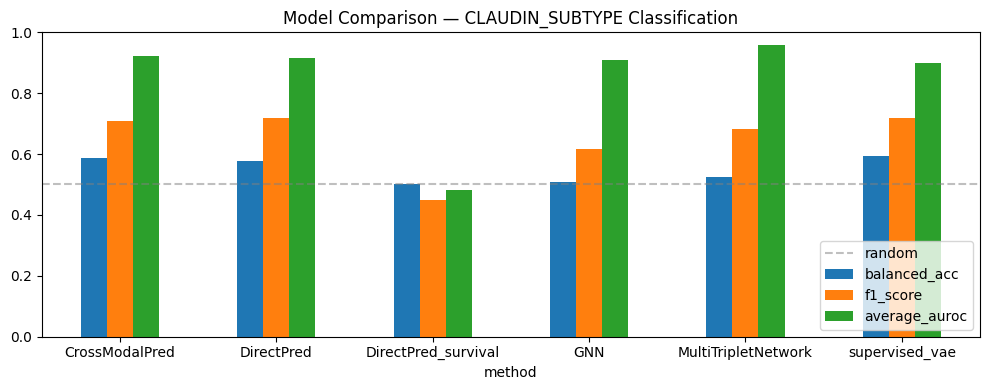

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
pivot[['balanced_acc', 'f1_score', 'average_auroc']].plot(
    kind='bar', ax=ax, rot=0
)
ax.set_title('Model Comparison — CLAUDIN_SUBTYPE Classification')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='random')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [36]:
# Feature importance 계산 (Integrated Gradients / GradientShap via Captum)
# compute_feature_importance(dataset, var, method='IntegratedGradients')
# method: 'IntegratedGradients' (default) or 'GradientShap'
model_dp.compute_feature_importance(train_dataset, 'CLAUDIN_SUBTYPE')

flexynesis.utils.get_important_features(
    model_dp,                    # feature importance가 계산된 모델
    var='CLAUDIN_SUBTYPE',       # 확인할 타겟 변수
    top=15,                      # 상위 N개 반환 (default: 20)
    # 반환: layer, name, target_class, importance 컬럼 포함 DataFrame
)

/home/cykim/flexynesis/flexynesis/utils.py:953: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,target_variable,target_class,target_class_label,layer,name,importance
0,CLAUDIN_SUBTYPE,0,Basal,gex,CHEK1,0.065289
1,CLAUDIN_SUBTYPE,0,Basal,gex,VAMP5,0.058433
2,CLAUDIN_SUBTYPE,0,Basal,gex,ARMT1,0.055017
3,CLAUDIN_SUBTYPE,0,Basal,gex,TMEM123,0.053406
4,CLAUDIN_SUBTYPE,0,Basal,gex,PRNP,0.052028
...,...,...,...,...,...,...
100,CLAUDIN_SUBTYPE,6,claudin-low,gex,CAV1,0.083017
101,CLAUDIN_SUBTYPE,6,claudin-low,gex,LOC146880,0.082042
102,CLAUDIN_SUBTYPE,6,claudin-low,gex,SRPX,0.080470
103,CLAUDIN_SUBTYPE,6,claudin-low,gex,TGFBR2,0.079978
